# Siemens Advanta- Bussines Case Project 2025/2026

**Project developed by Group V**:
   - Alano Gonçalves (20250457)
   - Catarina Martins (20221914)
   - João Carichas (20250507)
   - Marta Ribeiro (20221886)
   - Nicole Nogueira(20221961)

## 1. Import the needed libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
from math import ceil
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score   
from sklearn.impute import KNNImputer 
import zipfile
import xml.etree.ElementTree as ET
import matplotlib.ticker as mticker
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.metrics import mean_squared_error
import warnings
warnings.filterwarnings('ignore')

## 2. Data importation

In [2]:
MARKET_PATH = 'Case2_market_data_share.xlsx'
df_market = pd.read_excel(MARKET_PATH, sheet_name='Sheet1')
df_period_map = pd.read_excel(MARKET_PATH, sheet_name='Sheet2')

In [3]:
df_merged = pd.read_csv('df_merged_1.csv')

## 3. Data exploration and understanding

### 3.1. Data Overview

In [4]:
df_merged.tail()

,Business_Unit,Segment,Subsegment,Period,Biz_Desc,Orders,Revenue,China_Core_Inflation_Rate,China_Exports,China_GDP,...,United_States_GDP_from_Construction,United_States_GDP_from_Manufacturing,United_States_Industrial_Production,United_States_Industrial_Production_Mom,United_States_Inflation_Rate,United_States_Interest_Rate,United_States_Steel_Production,Date,Start_Period,End_Period
5623,SSI070,SSI07099,SSI07099,38,NaN,0,0,0.6,301.60,18270.36,...,863.2,2314.1,-0.1,0.6,3.3,5.5,6900.0,2024-05-01,15,24
5624,SSI070,SSI07099,SSI07099,39,NaN,0,0,0.6,307.24,18270.36,...,870.0,2368.9,0.8,0.0,3.0,5.5,6700.0,2024-06-01,15,24
5625,SSI070,SSI07099,SSI07099,40,NaN,0,0,0.4,300.22,18270.36,...,870.0,2368.9,-0.9,-0.9,2.9,5.5,6900.0,2024-07-01,15,24
5626,SSI070,SSI07099,SSI07099,41,NaN,0,0,0.3,308.24,18270.36,...,870.0,2368.9,-0.4,0.5,2.5,5.5,7000.0,2024-08-01,15,24
5627,SSI070,SSI07099,SSI07099,42,NaN,0,0,0.1,303.37,18270.36,...,872.5,2389.0,-1.2,-0.6,2.4,5.0,6700.0,2024-09-01,15,24


In [5]:
#overview the dataset
df_merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5628 entries, 0 to 5627
Data columns (total 84 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Business_Unit                             5628 non-null   object 
 1   Segment                                   5628 non-null   object 
 2   Subsegment                                5628 non-null   object 
 3   Period                                    5628 non-null   int64  
 4   Biz_Desc                                  4237 non-null   object 
 5   Orders                                    5628 non-null   int64  
 6   Revenue                                   5628 non-null   int64  
 7   China_Core_Inflation_Rate                 5628 non-null   float64
 8   China_Exports                             5628 non-null   float64
 9   China_GDP                                 5628 non-null   float64
 10  China_GDP_from_Construction         

In [6]:
#checking number of missing values
df_merged.isna().sum()

Business_Unit                        0
Segment                              0
Subsegment                           0
Period                               0
Biz_Desc                          1391
                                  ... 
United_States_Interest_Rate          0
United_States_Steel_Production       0
Date                                 0
Start_Period                         0
End_Period                           0
Length: 84, dtype: int64

In [7]:
#checking missing values after merging 
pd.set_option('display.max_rows', None)
df_merged.isna().sum()/len(df_merged) * 100

Business_Unit                                0.000000
Segment                                      0.000000
Subsegment                                   0.000000
Period                                       0.000000
Biz_Desc                                    24.715707
Orders                                       0.000000
Revenue                                      0.000000
China_Core_Inflation_Rate                    0.000000
China_Exports                                0.000000
China_GDP                                    0.000000
China_GDP_from_Construction                  0.000000
China_GDP_from_Manufacturing                 0.000000
China_Industrial_Production                  0.000000
China_Industrial_Production_Mom              0.000000
China_Inflation_Rate                         0.000000
China_Interest_Rate                          0.000000
China_Steel_Production                       0.000000
France_Core_Inflation_Rate                   0.000000
France_Exports              

In [4]:
# count how many distinct subsegments each segment has
subseg_counts = (
    df_merged.groupby('Segment')['Subsegment']
    .nunique()
    .reset_index()
    .rename(columns={'Subsegment': 'Subseg_Count'})
)

df_merged = df_merged.merge(subseg_counts, on='Segment', how='left')

# only flag as direct if segment = subsegment AND it's the only subsegment
df_merged['Is_Direct'] = (
    (df_merged['Segment'] == df_merged['Subsegment']) &
    (df_merged['Subseg_Count'] == 1)
)

print("Direct cases (segment = subsegment, no other subsegments):")
print(df_merged[df_merged['Is_Direct']]['Segment'].unique())
print("Count of direct segments:", df_merged[df_merged['Is_Direct']]['Segment'].nunique())

Direct cases (segment = subsegment, no other subsegments):
['SSI02792' 'SSI02793' 'SSI02796' 'SSI02798' 'SSI02799' 'SSI03784'
 'SSI03798' 'SSI03799' 'SSI04799' 'SSI07098' 'SSI07099']
Count of direct segments: 11


In [10]:
print("Shape:", df_merged.shape)
print("\nColumns:", df_merged.columns.tolist())
print("\nPeriod range:", df_merged['Period'].min(), "to", df_merged['Period'].max())
print("\nUnique BUs:", df_merged['Business_Unit'].nunique())
print("\nUnique segments:", df_merged['Segment'].nunique())
print("\nUnique subsegments:", df_merged['Subsegment'].nunique())
print("\nMissing values:", df_merged.isna().sum()[df_merged.isna().sum() > 0])
#print("\nDirect segments:", df_merged[df_merged['Is_Direct']]['Segment'].nunique())

Shape: (5628, 86)

Columns: ['Business_Unit', 'Segment', 'Subsegment', 'Period', 'Biz_Desc', 'Orders', 'Revenue', 'China_Core_Inflation_Rate', 'China_Exports', 'China_GDP', 'China_GDP_from_Construction', 'China_GDP_from_Manufacturing', 'China_Industrial_Production', 'China_Industrial_Production_Mom', 'China_Inflation_Rate', 'China_Interest_Rate', 'China_Steel_Production', 'France_Core_Inflation_Rate', 'France_Exports', 'France_GDP', 'France_GDP_from_Construction', 'France_GDP_from_Manufacturing', 'France_Industrial_Production', 'France_Industrial_Production_Mom', 'France_Inflation_Rate', 'France_Interest_Rate', 'Germany_Core_Inflation_Rate', 'Germany_Exports', 'Germany_GDP', 'Germany_GDP_from_Construction', 'Germany_GDP_from_Manufacturing', 'Germany_Industrial_Production', 'Germany_Industrial_Production_Mom', 'Germany_Inflation_Rate', 'Germany_Interest_Rate', 'Germany_Steel_Production', 'Italy_Core_Inflation_Rate', 'Italy_Exports', 'Italy_GDP', 'Italy_GDP_from_Construction', 'Italy_GDP

### 3.2. EDA and feature visualization

#### 3.2.1. Revenue over time per BUs / Segment

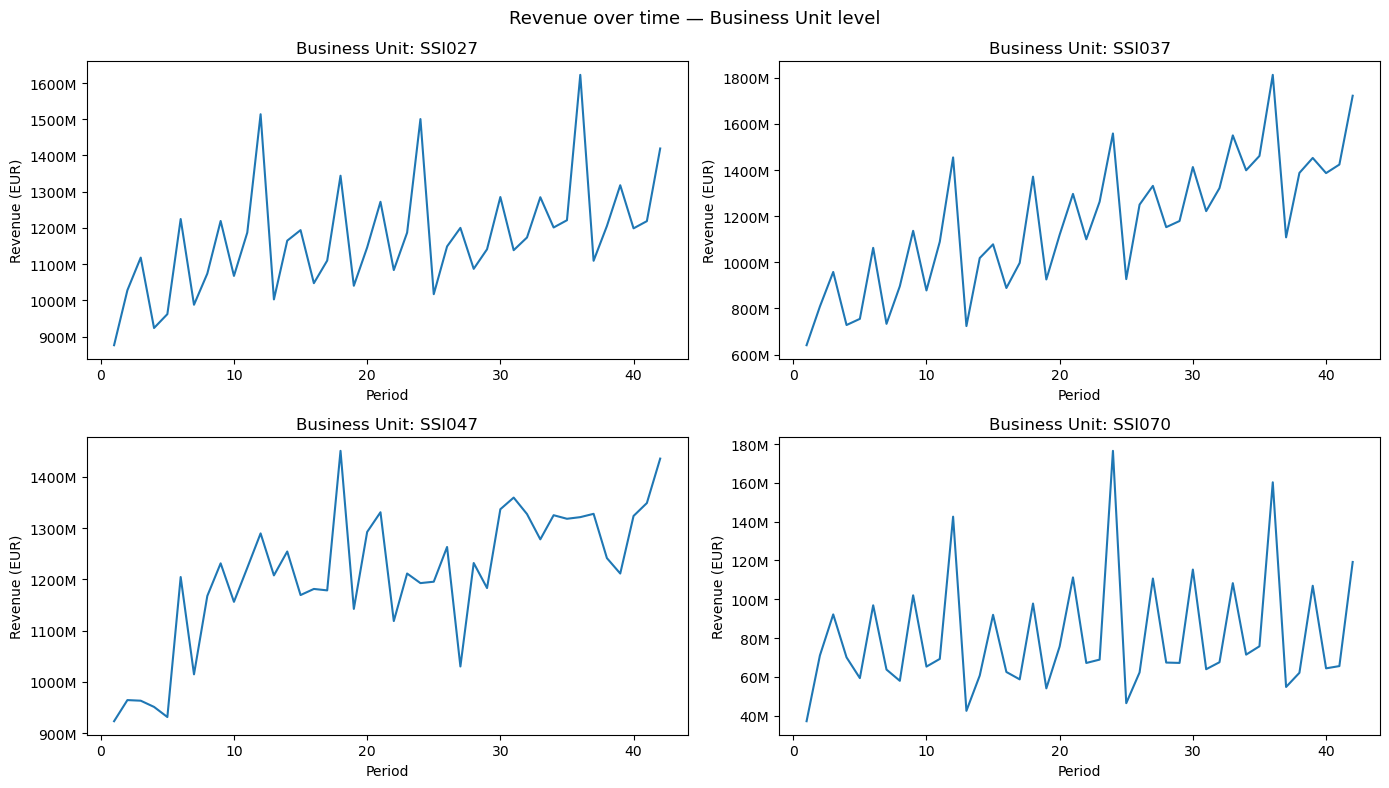

In [5]:
#revenue over time at BUSINESS UNIT level
bu_data = df_merged.groupby(['Period', 'Business_Unit'])['Revenue'].sum().reset_index()

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()
for i, bu in enumerate(sorted(bu_data['Business_Unit'].unique())):
    d = bu_data[bu_data['Business_Unit'] == bu]
    axes[i].plot(d['Period'], d['Revenue'])
    axes[i].set_title(f'Business Unit: {bu}')
    axes[i].set_xlabel('Period')
    axes[i].set_ylabel('Revenue (EUR)')
    axes[i].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))
plt.suptitle('Revenue over time — Business Unit level', fontsize=13)
plt.tight_layout()
plt.show()

- All 4 BUs show a generally upward trend over the 42 periods, which is good — it means there's a learnable trend signal for the model
- SSI027 appears to be the largest BU by revenue. 
- Some BUs show quite volatile month-to-month swings which suggests either genuine business volatility or that some subsegments dominate and skew the total.

SSI027:

- Relatively flat trend compared to the other BUs — revenue oscillates mostly between 0.9B and 1.3B with no strong directional drift. The most stable of the four.
- The volatility pattern looks somewhat periodic — there may be a weak seasonal cycle here, but it's hard to confirm without STL.
- The spike around period 25 (~1.6B) stands out as a potential outlier worth investigating.

SSI037:

- The strongest and most consistent upward trend of all four BUs — revenue roughly triples from ~0.6B to ~1.8B over the window. This BU is driving a big part of the World-level trend you saw in the previous plot.
- Despite the trend, there's still meaningful period-to-period volatility, meaning the trend alone won't be enough to forecast this well — you need to capture the residual fluctuations too.

SSI047:

- A moderate upward trend, similar in shape to SSI037 but less steep. Revenue grows from ~0.9B to ~1.4B.
- Notably the smoothest of the four BUs — the swings between consecutive periods are smaller. This is likely your most forecastable BU and potentially a good anchor for the middle-out approach at the BU level.

SSI070:

- Note the y-axis is 1e8, not 1e9 — this BU is an order of magnitude smaller than the others. It contributes very little to World-level totals but will matter for subsegment granularity.
- Very high relative volatility — the swings are large relative to the mean. This is the noisiest and hardest to forecast BU.
- There's a possible slight upward trend but it's completely obscured by the noise.

Cross-BU takeaways relevant to your modeling:

- SSI037 and SSI047 have the clearest structure and should get the most sophisticated models at BU level — Prophet or SARIMA with trend.
- SSI027 is stable and well-suited for ETS or a simpler seasonal model.
- SSI070 is problematic — given its size and noise, errors here won't significantly impact World-level RMSE, but you should flag it. A simple mean or naïve seasonal model may outperform complex ones for this BU.
- The fact that BUs behave so differently from each other confirms that a single global model across all BUs would struggle — fitting separate models per BU is the right call.

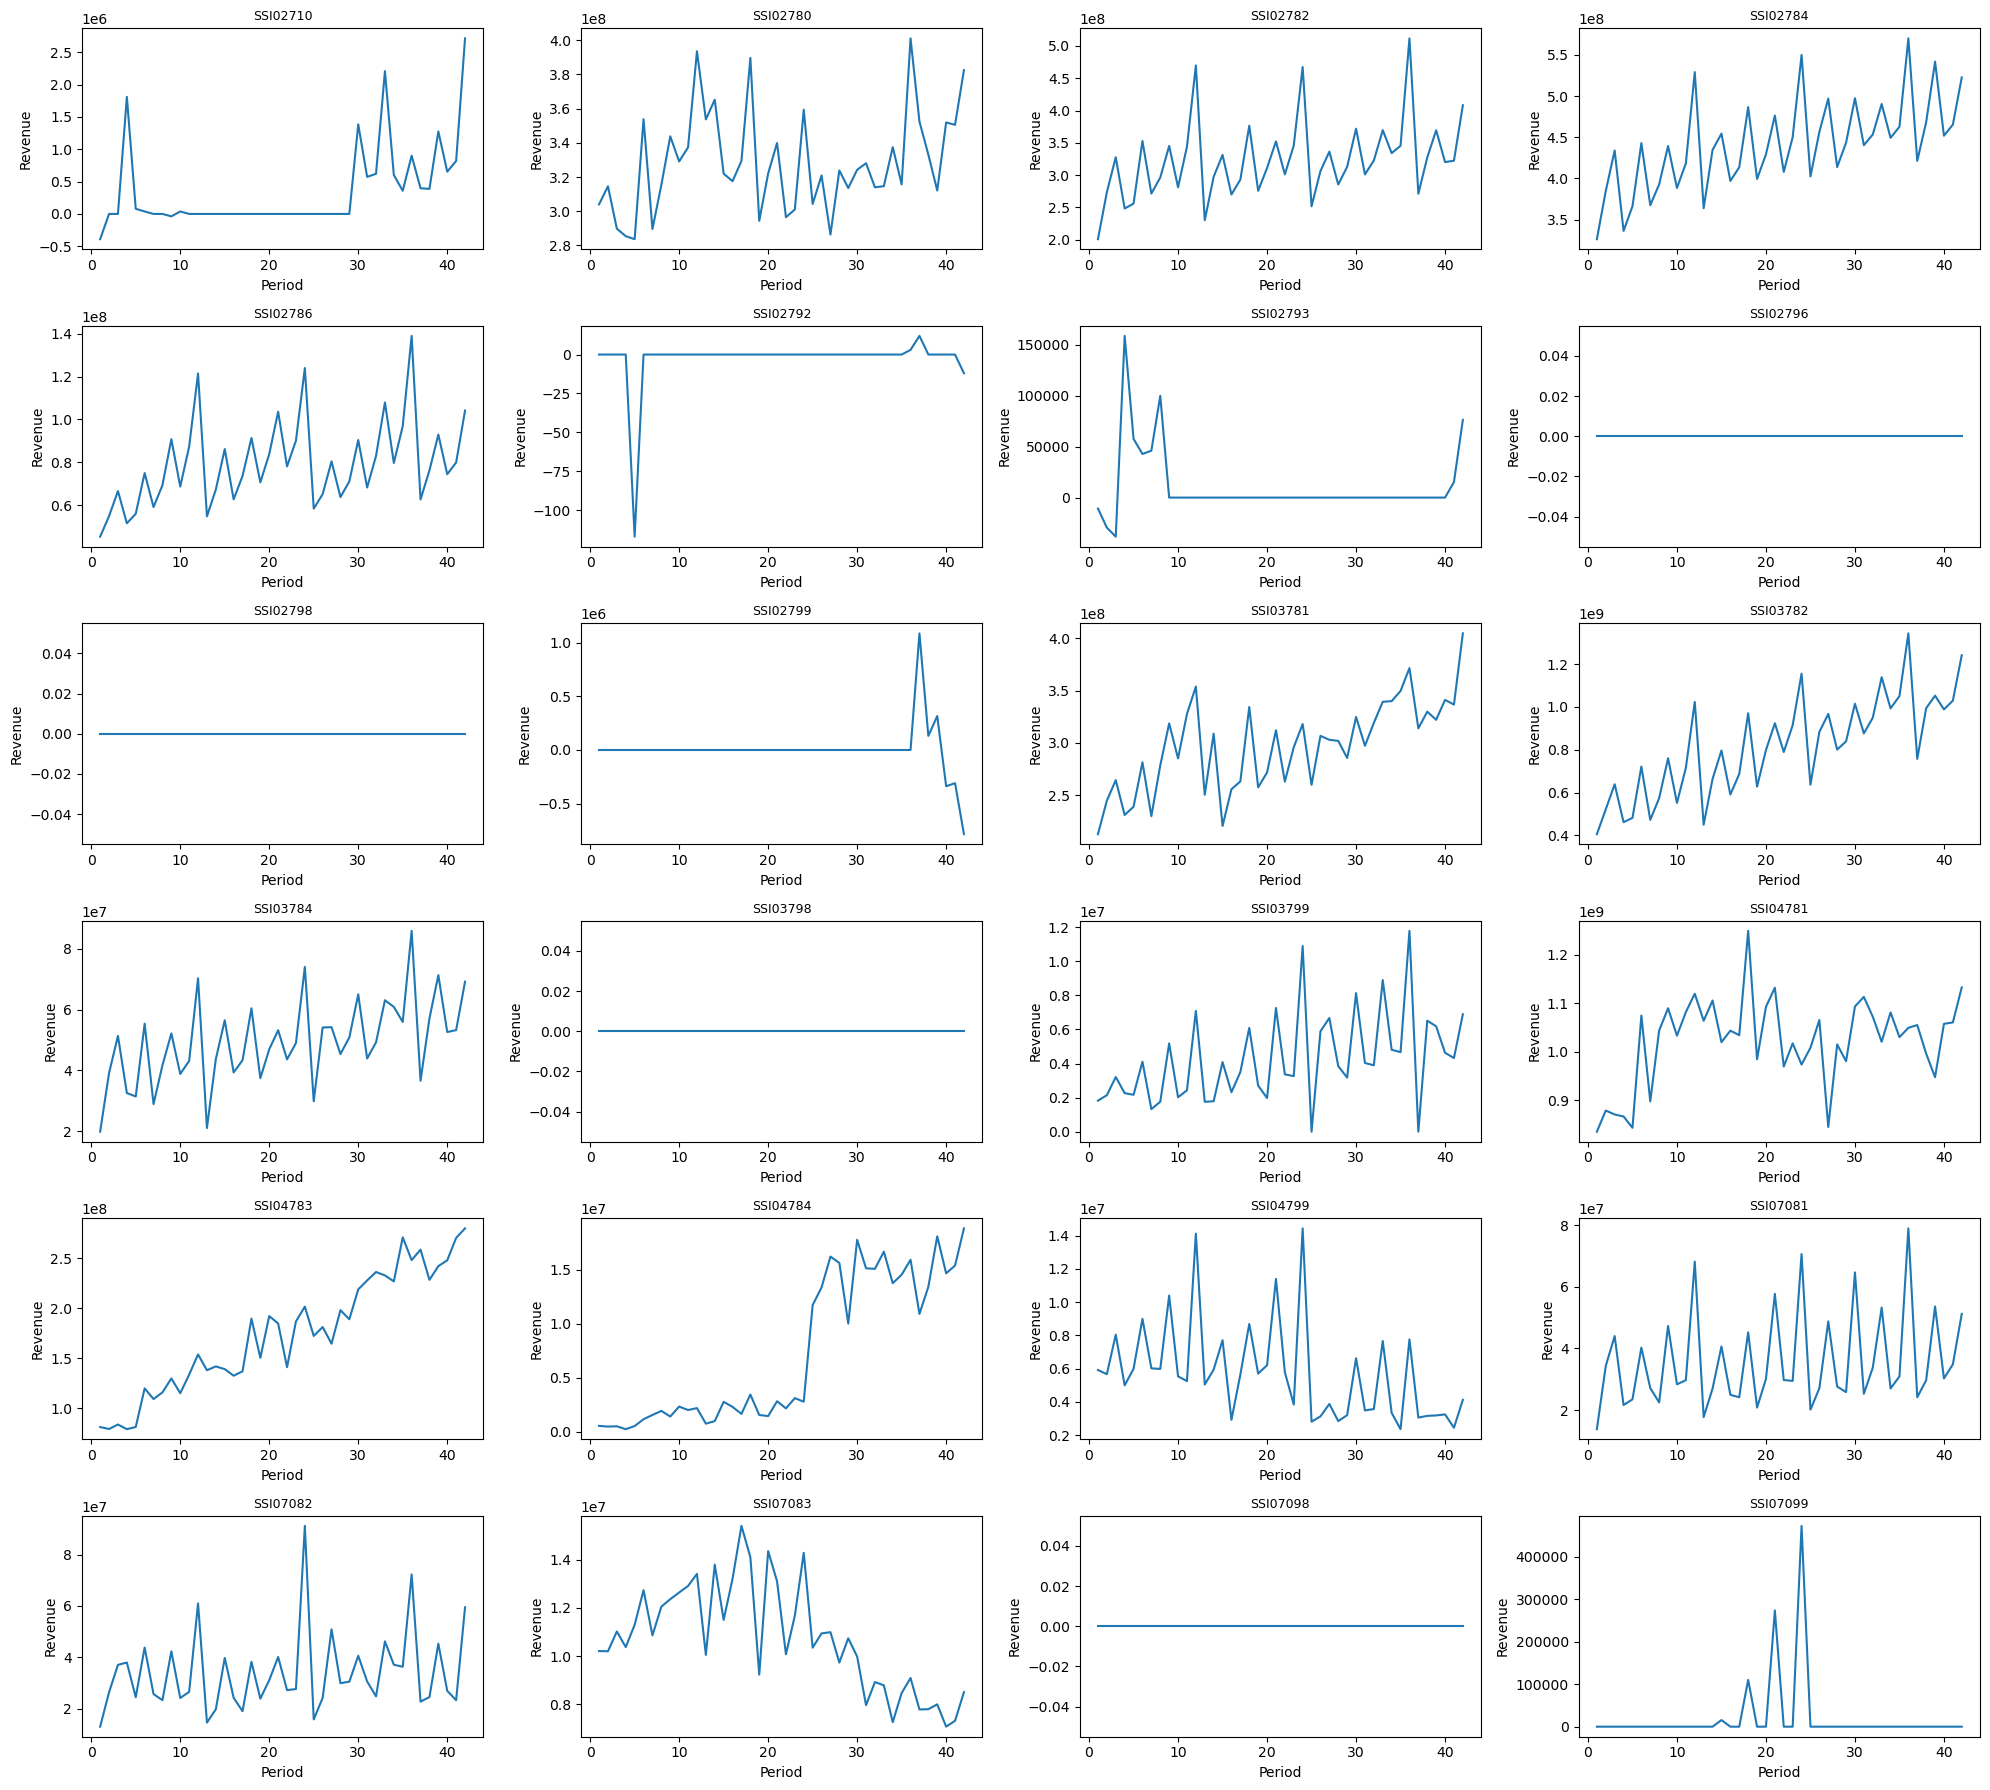

In [6]:
#revenue over time at SEGMENT level
segments = df_merged['Segment'].unique()

fig, axes = plt.subplots(nrows=6, ncols=4, figsize=(20, 18))
axes = axes.flatten()

for i, seg in enumerate(sorted(segments)):
    seg_data = (
        df_merged[df_merged['Segment'] == seg]
        .groupby('Period')['Revenue']
        .sum()
        .reset_index()
    )
    axes[i].plot(seg_data['Period'], seg_data['Revenue'])
    axes[i].set_title(seg, fontsize=9)
    axes[i].set_xlabel('Period')
    axes[i].set_ylabel('Revenue')

plt.tight_layout()
plt.show()

- Some segments are very stable and smooth — these will be easy to forecast. Others are extremely spiky or flat near zero for many periods — these are the problematic sparse ones we already identified. 
- The flat-near-zero segments are likely the ones with high sparsity from the chart.

Scale heterogeneity is extreme

- Y-axes range from 1e6 to 1e9 across segments — a 1000x difference in magnitude. This means a handful of large segments (SSI03782, SSI04781) will completely dominate any World-level error metric. Small segments could forecast terribly and barely affect your RMSE.

Several segments are essentially flat-zero

- SSI02796, SSI02798, SSI03798, SSI07098 show near-zero values throughout — these are either inactive, discontinued, or placeholder segments. They will cause problems in quota/distribution models (division by near-zero) and should be excluded or handled separately.

Structural breaks are common

- SSI02792 has a massive negative spike early on then flatlines — looks like a one-time accounting correction, not a real revenue pattern.
- SSI02793 has very high early values then drops to near-zero and stays there — a discontinued product line or restructuring event. Modeling this as a continuous series makes no sense.
- SSI02799 and SSI04784 show sudden jumps from zero to active mid-series — new product launches. These series have effectively fewer than 42 usable periods.

Two dominant behavior archetypes

- About half the segments show a clear upward trend with moderate volatility (SSI02784, SSI03781, SSI03782, SSI04781, SSI04783) — these are your well-behaved, forecastable segments and should be your middle-out anchor candidates.
- The other half show high spikiness with no clear trend (SSI02780, SSI02782, SSI02786, SSI03784, SSI07081) — these are harder to model and will likely need simpler approaches like ETS or seasonal naïve.

Seasonality is visible in several segments

- Segments like SSI02784, SSI02786, SSI03781, SSI04783 show fairly regular oscillations on top of their trend — this is promising and suggests STL decomposition will find a usable seasonal component at the segment level.
- The spike-dominated segments (SSI07081, SSI07082) look more like intermittent demand than seasonal patterns — different modeling treatment needed.

Practical implications for your pipeline:

- You likely want to exclude or separately handle the flat-zero and structurally broken segments before fitting any models.
- The middle-out anchor should come from the well-behaved trending segments — they have the richest exploitable structure.
- Consider splitting segments into two groups — "well-behaved" and "problematic" — and applying different model strategies to each rather than one uniform approach.


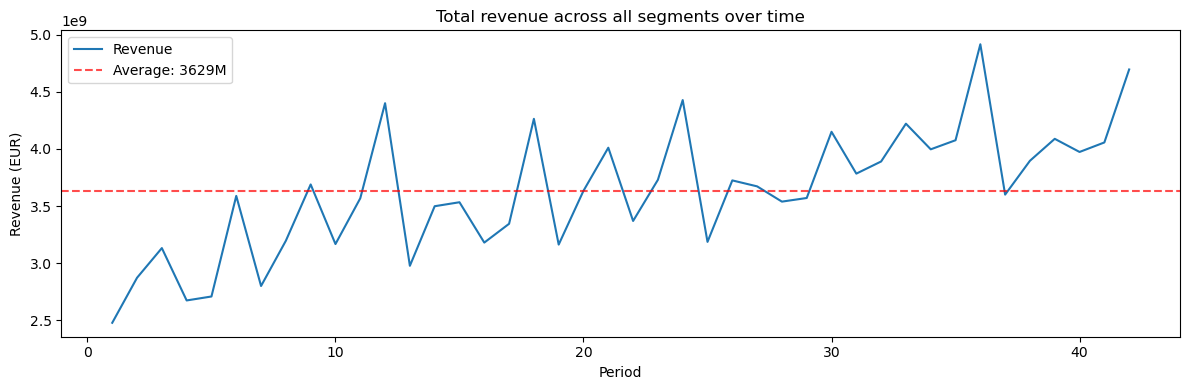

In [13]:
total_revenue = df_merged.groupby('Period')['Revenue'].sum().reset_index()

plt.figure(figsize=(12, 4))
plt.plot(total_revenue['Period'], total_revenue['Revenue'], label='Revenue')
plt.axhline(total_revenue['Revenue'].mean(), color='red', linestyle='--', 
            alpha=0.7, label=f'Average: {total_revenue["Revenue"].mean()/1e6:.0f}M')
plt.title('Total revenue across all segments over time')
plt.xlabel('Period')
plt.ylabel('Revenue (EUR)')
plt.legend()
plt.tight_layout()
plt.show()

- There's a clear upward trend overall with some cyclical variation. This is very useful — it confirms a trend component exists that SARIMA and Prophet can model well.

Revenue:

- Clear upward trend overall — the series goes from ~2.5B in early periods to ~4.7B by period 42, meaning the World-level revenue has roughly doubled over the data window. This is important — your models need to capture this trend explicitly.
- The series is not stationary — the mean is visibly drifting upward, which the ADF test will likely confirm. You'll need to either detrend or difference before feeding into certain models.
- There's notable volatility around the trend — big swings up and down between consecutive periods. This suggests either genuine business cyclicality or that some periods aggregate differently (e.g., fiscal quarter-end effects).
- The red mean line sits well below the recent periods, further confirming the trend — the mean is being pulled down by the early low-value periods and is not a good summary statistic for this series.

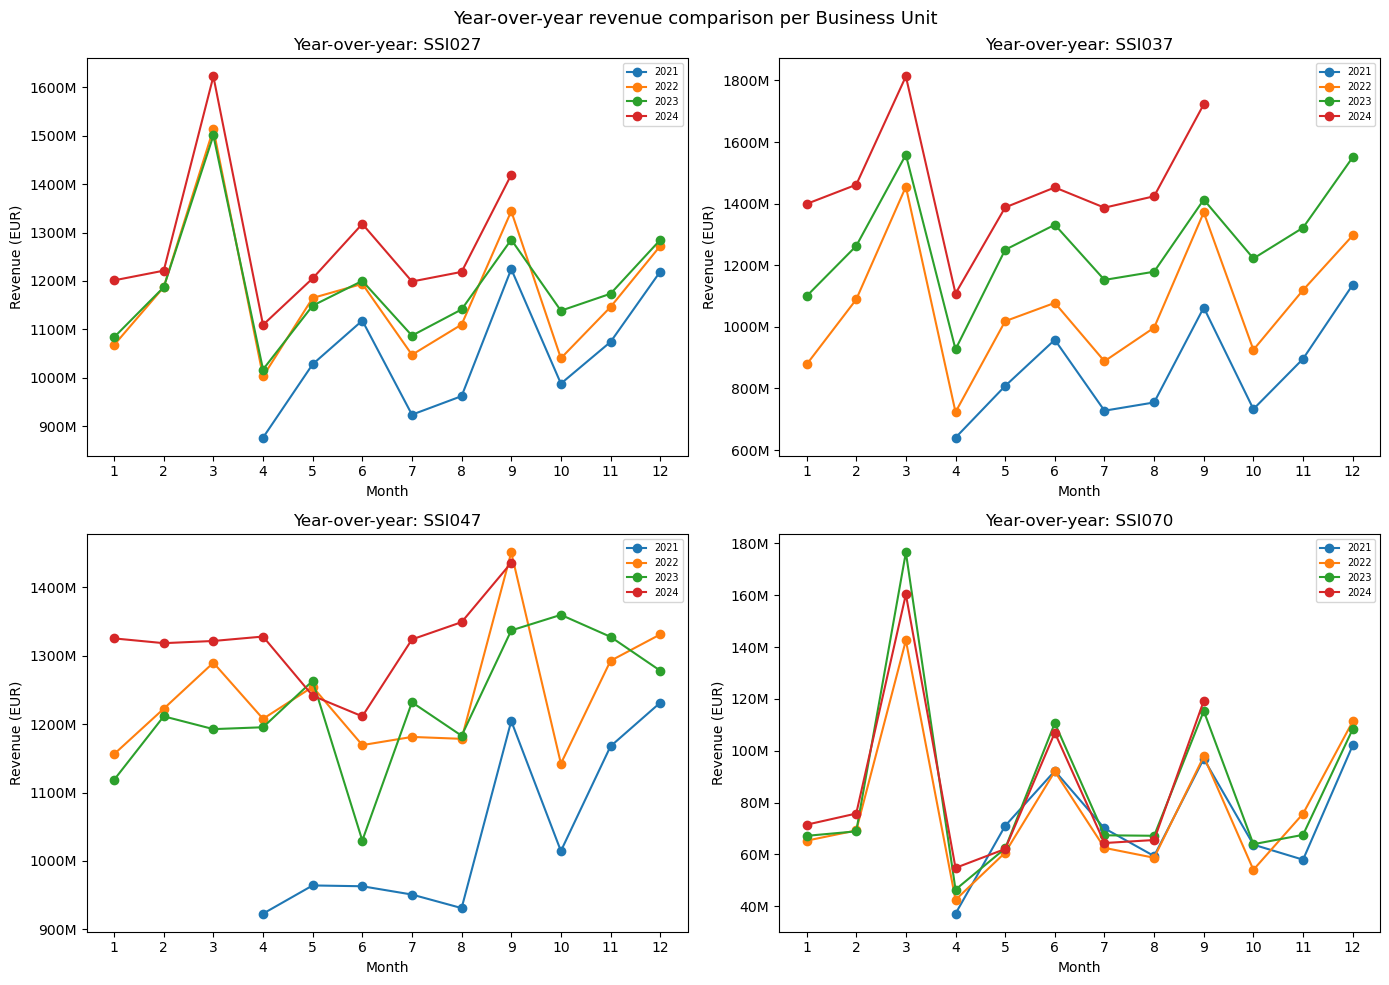

In [7]:
#Year-over-year comparison per BU
df_merged['Month'] = pd.to_datetime(df_merged['Date']).dt.month
df_merged['Year']  = pd.to_datetime(df_merged['Date']).dt.year

bu_list = sorted(df_merged['Business_Unit'].unique())
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
for i, bu in enumerate(bu_list):
    d = df_merged[df_merged['Business_Unit'] == bu]
    yoy = d.groupby(['Year', 'Month'])['Revenue'].sum().reset_index()
    for year in sorted(yoy['Year'].unique()):
        y_data = yoy[yoy['Year'] == year]
        axes[i].plot(y_data['Month'], y_data['Revenue'], marker='o', label=str(year))
    axes[i].set_title(f'Year-over-year: {bu}')
    axes[i].set_xlabel('Month')
    axes[i].set_ylabel('Revenue (EUR)')
    axes[i].set_xticks(range(1, 13))
    axes[i].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))
    axes[i].legend(fontsize=7)
plt.suptitle('Year-over-year revenue comparison per Business Unit', fontsize=13)
plt.tight_layout()
plt.show()

In [8]:
#Heatmap of revenue by segment × period
heatmap_data = (
    seg_data.pivot(index='Segment', columns='Period', values='Revenue')
    .fillna(0)
)

fig, ax = plt.subplots(figsize=(18, 8))
sns.heatmap(
    heatmap_data / 1e6,
    ax=ax,
    cmap='YlOrRd',
    linewidths=0.3,
    linecolor='gray',
    cbar_kws={'label': 'Revenue (EUR millions)'}
)
ax.set_title('Revenue heatmap — Segment × Period')
ax.set_xlabel('Period')
ax.set_ylabel('Segment')
plt.tight_layout()
plt.show()

KeyError: 'Segment'

#### 3.2.2. Checking Seasonality

In [ ]:
from statsmodels.tsa.seasonal import STL

total_revenue = df_merged.groupby('Period')['Revenue'].sum().reset_index()

stl = STL(total_revenue['Revenue'], period=12, robust=True)
result = stl.fit()

fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
axes[0].plot(total_revenue['Period'], total_revenue['Revenue'])
axes[0].set_title('Observed')
axes[1].plot(total_revenue['Period'], result.trend)
axes[1].set_title('Trend')
axes[2].plot(total_revenue['Period'], result.seasonal)
axes[2].set_title('Seasonal')
axes[3].plot(total_revenue['Period'], result.resid)
axes[3].axhline(0, color='red', linestyle='--', alpha=0.5)
axes[3].set_title('Residual')
plt.suptitle('STL Decomposition — Total Revenue', fontsize=13)
plt.tight_layout()
plt.show()

Trend

- Almost perfectly linear upward trend from ~3.0B to ~4.3B over the 42 periods. This is the dominant component of the series and your models must capture it — any model that assumes a stationary mean will underperform significantly.
- The linearity is good news — a simple linear trend term or first-differencing will be sufficient. You don't need a complex nonlinear trend model.

Seasonal

- Seasonality is real and strong — the seasonal component oscillates between roughly -0.5B and +1.0B, which is a swing of ~1.5B on a series whose total range is ~2.5B. That means seasonality explains a very large share of the period-to-period variation you saw in the observed plot.
- The pattern is not perfectly regular — some seasonal peaks are much larger than others (e.g., the spike around period 13–14 and again around period 25). This asymmetry suggests the seasonal amplitude may be growing with the trend, which would mean a multiplicative rather than additive seasonality model could fit better. Worth testing both.
- With only ~3.5 full seasonal cycles in 42 periods, the STL is doing its best but the seasonal estimate has uncertainty — don't over-rely on the exact shape.

Residual

- The residuals are on the order of 1e8, while the observed series is 1e9 — so residuals are roughly 10% of the signal. That's reasonably small, meaning the trend + seasonal components together explain ~90% of the variance. Good.
- However the residuals are not pure white noise — there's a cluster of large residuals around periods 15–25, which coincides with what appeared to be higher volatility in the observed plot. This could be a real business event (COVID disruption period) or a sign that the seasonal pattern shifted mid-series.
- The residuals settle down to near-zero after period 30, which is actually encouraging for forecasting — the most recent periods are the cleanest.

Overall STL takeaway for your pipeline:

- Confirmed: trend + seasonality are both worth modeling explicitly — neither can be ignored.
- The World level is well-behaved enough that Prophet (which handles linear trend + Fourier seasonality natively) or Holt-Winters with additive/multiplicative seasonality will work well here.
- The residual cluster in the middle periods is worth flagging — if those correspond to COVID years (roughly 2021–2022 given your date range), you may want to add a dummy regressor for that window to prevent the model from treating it as a seasonal pattern.

In [ ]:
total_revenue['month_pos'] = total_revenue['Period'] % 12

fig, ax = plt.subplots(figsize=(12, 5))
sns.boxplot(data=total_revenue, x='month_pos', y='Revenue', ax=ax)
ax.axhline(total_revenue['Revenue'].mean(), color='red', linestyle='--', 
           alpha=0.5, label='Overall mean')
ax.set_title('Total Revenue by Month Position (seasonal pattern check)')
ax.set_xlabel('Period mod 12 (month proxy)')
ax.set_ylabel('Revenue (EUR)')
ax.legend()
plt.tight_layout()
plt.show()

The seasonal pattern that emerges

Position 0 is clearly the highest revenue month — median ~4.6B, well above the overall mean. This corresponds to one specific calendar month that consistently outperforms.
Position 1 is the lowest — median ~3.1B, the furthest below the mean. The drop from position 0 to position 1 is the sharpest transition in the entire cycle.
Position 6 is a secondary peak — median ~4.2B, the second highest position. This suggests a bimodal seasonal pattern with peaks roughly 6 months apart, which is common in B2B industrial sales (two strong booking/delivery cycles per year).
Positions 7 is a secondary trough, mirroring position 1 on the other side of the year.
The overall shape roughly follows: high → low → medium → medium → medium → high → low → medium — a wave with two cycles per year.

The caveat — this is a proxy, not exact months

Because your periods are anonymized and you're using period mod 12 as a month proxy, position 0 may not actually correspond to January. The relative pattern is valid but you cannot label these as specific calendar months without mapping back through the date column you have. You should do that mapping — df_merged.groupby('Period')['Date'].first() will give you the actual calendar month for each period position, which will make this plot interpretable in business terms.

Box widths reveal trend contamination

The boxes at position 0 and 6 are very tight (low variance across the ~3 observations per position) — meaning those peaks are consistent year over year, which is strong evidence of genuine seasonality.
Positions 2–5 and 8–11 have wider boxes — more variance, meaning those middle months are less predictable and more influenced by the underlying trend or random shocks.
This is actually a known artifact of doing this analysis on a trending series — the upward trend means later-year observations of each month position are systematically higher than earlier ones, inflating box width. Ideally you'd detrend first before making this plot, but the pattern is clear enough to trust regardless.

Modeling implications:

The bimodal seasonal pattern with a period-6 secondary peak is important to communicate to your model. A standard annual seasonality assumption (period=12) will capture it, but make sure your seasonal period parameter is set to 12 and not a shorter cycle.
The consistency of the peaks at positions 0 and 6 means these are the most forecastable points in the cycle — your model should nail those. If it doesn't, something is wrong with the seasonal specification.
Since you have the actual Date column, map the positions to real months before finalizing your EDA — knowing whether the peak is September vs December is meaningful for the business stakeholder presentation.

In [ ]:
df_merged['Month'] = pd.to_datetime(df_merged['Date']).dt.month

seasonality = (
    df_merged.groupby(['Business_Unit', 'Month'])['Revenue']
    .mean()
    .reset_index()
)

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()
for i, bu in enumerate(sorted(df_merged['Business_Unit'].unique())):
    d = seasonality[seasonality['Business_Unit'] == bu]
    axes[i].bar(d['Month'], d['Revenue'])
    axes[i].set_title(f'Seasonality: {bu}')
    axes[i].set_xlabel('Month of year')
    axes[i].set_ylabel('Avg Revenue (EUR)')
    axes[i].set_xticks(range(1, 13))
    axes[i].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))
plt.suptitle('Average revenue by month of year — seasonality check', fontsize=13)
plt.tight_layout()
plt.show()

- There seems to be some seasonal pattern — certain months consistently show higher revenue than others. This is important because it confirms that including a month-of-year feature will help our model to make good predictions. 
- Month 3 (March) is usually the month with higher revenue in all business units except for SSI047. Moreover, September and December also show to be relevant in terms of revenue. 

#### 3.2.3. Hierarchy Proportions

In [ ]:
seg_totals = (
    df_merged.groupby(['Period', 'Segment'])['Revenue']
    .sum()
    .reset_index()
    .rename(columns={'Revenue': 'Seg_Revenue'})
)

df_prop = df_merged.merge(seg_totals, on=['Period', 'Segment'], how='left')
df_prop['Proportion'] = df_prop['Revenue'] / df_prop['Seg_Revenue'].replace(0, np.nan)

avg_proportions = (
    df_prop.groupby(['Business_Unit', 'Segment', 'Subsegment'])['Proportion']
    .mean()
    .reset_index()
    .rename(columns={'Proportion': 'Avg_Proportion'})
    .sort_values(['Business_Unit', 'Segment', 'Avg_Proportion'], ascending=[True, True, False])
)

# display ALL proportions grouped by segment
pd.set_option('display.max_rows', None)
print("=== SUBSEGMENT PROPORTIONS WITHIN EACH SEGMENT ===")
print(avg_proportions.to_string(index=False))
pd.reset_option('display.max_rows')

In [ ]:
#Subsegment proportion stability over time
seg_totals = (
    df_merged.groupby(['Period', 'Segment'])['Revenue']
    .sum()
    .reset_index()
    .rename(columns={'Revenue': 'Seg_Revenue'})
)
df_prop = df_merged.merge(seg_totals, on=['Period', 'Segment'], how='left')
df_prop['Proportion'] = df_prop['Revenue'] / df_prop['Seg_Revenue'].replace(0, np.nan)

# plot proportion stability for each segment
for seg in segments:
    seg_sub = df_prop[df_prop['Segment'] == seg]
    subsegments = seg_sub['Subsegment'].unique()

    if len(subsegments) <= 1:
        continue

    fig, ax = plt.subplots(figsize=(12, 4))
    for sub in subsegments:
        d = seg_sub[seg_sub['Subsegment'] == sub].sort_values('Period')
        ax.plot(d['Period'], d['Proportion'], label=sub, marker='o', markersize=3)
    ax.set_title(f'Proportion stability over time — Segment {seg}')
    ax.set_xlabel('Period')
    ax.set_ylabel('Share of segment revenue')
    ax.legend(fontsize=7, bbox_to_anchor=(1.01, 1), loc='upper left')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0%}'))
    plt.tight_layout()
    plt.show()

#### 3.2.4. Checking Sparsity — zero percentage per subsegment

In [ ]:
zero_pct = (
    df_merged.groupby(['Segment', 'Subsegment'])
    .apply(lambda x: (x['Revenue'] == 0).sum() / len(x) * 100)
    .reset_index()
    .rename(columns={0: 'Zero_Pct'})
    .sort_values('Zero_Pct', ascending=False)
)

fig, ax = plt.subplots(figsize=(10, 18))
colors = ['red' if z > 50 else 'orange' if z > 20 else 'green' for z in zero_pct['Zero_Pct']]
ax.barh(zero_pct['Subsegment'], zero_pct['Zero_Pct'], color=colors)
ax.axvline(50, color='red', linestyle='--', label='50% threshold')
ax.axvline(20, color='orange', linestyle='--', label='20% threshold')
ax.set_xlabel('% of months with zero revenue')
ax.set_title('Sparsity per subsegment (% zero revenue months)')
ax.tick_params(axis='y', labelsize=7)
ax.legend()
plt.tight_layout()
plt.show()

- A large proportion of subsegments are red (>50% zero months). This is a critical finding — it means many subsegments are too sparse to model individually with any reliability. 

In [ ]:
print("\nSubsegments with >50% zero months (consider excluding from model):")
print(zero_pct[zero_pct['Zero_Pct'] > 50][['Segment', 'Subsegment', 'Zero_Pct']].to_string(index=False))

#### 3.2.5. Correlation between Market Variables and Total Revenue

In [ ]:
market_cols = [c for c in df_merged.columns if any(
    c.startswith(country) for country in
    ['Germany', 'France', 'China', 'Italy', 'Japan',
     'Switzerland', 'United_Kingdom', 'United_States']
)]

total_rev_period = df_merged.groupby('Period')['Revenue'].sum().reset_index()
market_period    = df_merged.groupby('Period')[market_cols].mean().reset_index()
corr_df          = total_rev_period.merge(market_period, on='Period')

correlations = (
    corr_df[market_cols]
    .corrwith(corr_df['Revenue'])
    .abs()
    .sort_values(ascending=False)
    .reset_index()
)
correlations.columns = ['Market_Variable', 'Abs_Correlation']

print("\n=== TOP 20 MARKET VARIABLES CORRELATED WITH TOTAL REVENUE ===")
print(correlations.head(20).to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 8))
top20 = correlations.head(20)
ax.barh(top20['Market_Variable'], top20['Abs_Correlation'])
ax.set_xlabel('Absolute correlation with total revenue')
ax.set_title('Top 20 market variables correlated with revenue')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

- GDP variables dominate the top correlations, which makes economic sense — Siemens infrastructure products correlate with economic activity. However, it is important to note that we forward-filled the GDP columns, so these correlations might be slightly inflated. 
- Interest rates also appear strongly, which makes sense for capital-intensive industrial products. 

In [ ]:
macro_cols = [c for c in df_merged.columns if any(
    c.startswith(x) for x in ['Germany', 'China', 'United_States', 'France']
)]

macro_df = df_merged.groupby('Period')[macro_cols].mean()
macro_df['Revenue'] = total_revenue.set_index('Period')['Revenue']

corr_with_revenue = (
    macro_df.corr()['Revenue']
    .drop('Revenue')
    .sort_values(key=abs, ascending=False)
)

plt.figure(figsize=(10, 8))
corr_with_revenue.head(20).plot(
    kind='barh',
    color=['green' if x > 0 else 'red' for x in corr_with_revenue.head(20)]
)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Top 20 macro indicators — correlation with total revenue')
plt.xlabel('Pearson correlation')
plt.tight_layout()
plt.show()

In [ ]:
seg_data = df_merged.groupby(['Period', 'Segment'])['Revenue'].sum().reset_index()
seg_pivot = seg_data.pivot(index='Period', columns='Segment', values='Revenue')
seg_diff  = seg_pivot.diff().dropna()

fig, ax = plt.subplots(figsize=(16, 12))
sns.heatmap(seg_diff.corr(), cmap='coolwarm', center=0, linewidths=0.3,
            xticklabels=True, yticklabels=True, ax=ax, annot=False)
ax.set_title('Segment revenue correlation (differenced series)', fontsize=12)
plt.tight_layout()
plt.show()

#### 3.2.6. ACF and PACF

In [ ]:
##ACF / PACF in general 
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(total_revenue['Revenue'], lags=20, ax=axes[0], title='ACF — Total Revenue')
plot_pacf(total_revenue['Revenue'], lags=20, ax=axes[1], title='PACF — Total Revenue')
plt.tight_layout()
plt.show()

ACF (left)

Lag 1 is significant and positive (~0.30) — the series has meaningful short-term autocorrelation, meaning last period's revenue is a useful predictor of this period's. This is expected and healthy.
Lag 6 spikes strongly (~0.60) and lag 12 spikes again (~0.55) — this is the clearest confirmation yet of the bimodal seasonal pattern you saw in the boxplot. Revenue 6 periods ago and 12 periods ago are strongly correlated with today's value. This is your seasonal signature.
The slow decay of the ACF rather than a sharp cutoff indicates the series is non-stationary — the trend is creating persistent autocorrelation that extends many lags out. This confirms what the STL trend showed — you need to account for the trend before or within your model.
Negative values appearing after lag 13–14 are typical of a series with a strong seasonal cycle — you're seeing the "opposite phase" of the seasonal pattern.

PACF (right)

Significant spikes at lags 1, 2, and 6 — after controlling for intermediate lags, these are the direct predictors.
The spike at lag 6 (~0.48) in the PACF is particularly important — it directly confirms a 6-period seasonal cycle that isn't just inherited from shorter lags.
After lag 6, the PACF drops into the confidence band — meaning lags beyond 6 don't add much direct predictive power once you've accounted for lags 1, 2, and 6.

What this means for model specification:

If using SARIMA, a reasonable starting point is SARIMA(2,1,0)(1,1,0)[6] or (1,1,0)(1,1,0)[12] — the non-seasonal part needs at least AR(2) based on PACF lags 1 and 2, and the seasonal part needs period 6 or 12.
If using Prophet, set seasonality_mode to test both additive and multiplicative, and add a custom 6-period Fourier seasonality on top of the default annual one.
If using LightGBM, include lag features at t-1, t-2, and t-6 as a minimum — those are your three most important lag predictors based on the PACF.
The confidence bands widen significantly at higher lags due to the small sample (42 observations) — treat anything beyond lag 10 with caution, the estimates are unreliable there.

Overall ACF/PACF summary for your pipeline:
The series has AR(2) short-term structure plus a strong seasonal component at period 6 (and harmonically at 12). It is non-stationary in levels. Any model that ignores either the trend or the 6-period seasonality will leave significant predictable variance on the table.

In [ ]:
##ACF / PACF per Business Unit
bu_data = df_merged.groupby(['Business_Unit', 'Period'])['Revenue'].sum().reset_index()

fig, axes = plt.subplots(4, 2, figsize=(14, 14))
for i, unit in enumerate(sorted(bu_data['Business_Unit'].unique())):
    data = bu_data[bu_data['Business_Unit'] == unit].sort_values('Period')['Revenue']
    plot_acf(data.values, lags=15, ax=axes[i][0], title=f'ACF — {unit}')
    plot_pacf(data.values, lags=15, ax=axes[i][1], title=f'PACF — {unit}')
plt.tight_layout()
plt.show()

SSI027

ACF shows clear spikes at lags 3, 6, and 12 — the same bimodal seasonal signature as the World level, which makes sense since SSI027 is one of the larger BUs.
PACF has significant spikes at lags 1 and 6 only — simpler AR structure than the World level, suggesting SARIMA(1,1,0)(1,1,0)[6] as a starting point.
Confidence bands are relatively tight — the autocorrelation estimates are reasonably reliable for this BU.

SSI037

ACF decays slowly and remains positive for many lags — classic non-stationary trending series signature, even stronger than what we saw at World level. The trend in SSI037 is so dominant it's bleeding into the autocorrelation structure.
PACF has significant spikes at lags 1, 2, and 6 — similar structure to the World level.
The slow ACF decay is a strong signal to apply first differencing before fitting any ARIMA-type model, or to let Prophet handle the trend natively. Don't fit a stationary model to this series.

SSI047

ACF drops off relatively quickly after lag 1–2 with modest spikes at lags 3 and 6 — the weakest seasonal autocorrelation of all four BUs, consistent with what we saw in the STL where its seasonal component was irregular.
PACF shows only lags 1 and 2 as clearly significant — suggests a simple AR(2) structure after detrending, with only weak seasonality to model.
This BU may actually forecast better with a trend model plus AR(2) residuals than with a full seasonal model.

SSI070

The most unusual pattern — ACF shows strong negative spikes at lags 2 and 8, and positive spikes at lags 3 and 12. This alternating positive/negative pattern in the ACF is a signature of a series that oscillates sharply, which matches the high volatility we saw in its time plot.
PACF has a very large negative spike at lag 2 (~-0.55) which is outside the confidence band — suggesting a MA component rather than pure AR. An ARIMA with a moving average term may fit better for SSI070 than a pure AR model.
Combined with the structural break in its trend, SSI070 remains the most problematic BU. Given all the evidence, seriously consider fitting it on periods 20–42 only and using a simpler model like ETS.

Cross-BU takeaways for modeling:

The lag-6 seasonal spike appears in SSI027 and SSI037 but is weaker in SSI047 and absent as a clean signal in SSI070 — meaning the bimodal seasonality is driven primarily by the two larger BUs and may not be a universal property of the hierarchy.
Fitting a single seasonal period assumption across all BUs would be a mistake — SSI047 and SSI070 need different specifications.
This further reinforces fitting separate models per BU rather than a pooled approach at this level.

In [ ]:
#ACF / PACF per segment
seg_data = df_merged.groupby(['Segment', 'Period'])['Revenue'].sum().reset_index()
segments = sorted(seg_data['Segment'].unique())

fig, axes = plt.subplots(len(segments), 2, figsize=(14, len(segments) * 3))
for i, seg in enumerate(segments):
    series = seg_data[seg_data['Segment'] == seg].sort_values('Period')['Revenue']
    plot_acf(series, lags=20, ax=axes[i, 0], title=f'ACF — {seg}')
    plot_pacf(series, lags=20, ax=axes[i, 1], title=f'PACF — {seg}')
plt.suptitle('Autocorrelation & Partial Autocorrelation per Segment', fontsize=13, y=1.001)
plt.tight_layout()
plt.show()


#### 3.2.7. Stationary test on all levels

In [ ]:
print("=== ADF Test Results (p < 0.05 = stationary) ===\n")

print("TOTAL REVENUE:")
p = adfuller(total_revenue['Revenue'])[1]
print(f"  Revenue: p = {p:.4f} → {'stationary' if p < 0.05 else 'NON-STATIONARY'}\n")

print("BUSINESS UNITS:")
for unit in sorted(bu_data['Business_Unit'].unique()):
    data = bu_data[bu_data['Business_Unit'] == unit].sort_values('Period')['Revenue']
    p = adfuller(data)[1]
    print(f"  {unit}: p = {p:.4f} → {'stationary' if p < 0.05 else 'NON-STATIONARY'}")

print("\nSEGMENTS:")
seg_data = df_merged.groupby(['Segment', 'Period'])['Revenue'].sum().reset_index()
for seg in sorted(seg_data['Segment'].unique()):
    data = seg_data[seg_data['Segment'] == seg].sort_values('Period')['Revenue']
    if data.nunique() < 2:
        print(f"  {seg}: SKIPPED (constant series)")
        continue
    p = adfuller(data)[1]
    print(f"  {seg}: p = {p:.4f} → {'stationary' if p < 0.05 else 'NON-STATIONARY'}")

Overall stationarity summary

The vast majority of series are non-stationary — this is consistent and expected given the upward trends visible throughout the EDA. First differencing or explicit trend modeling is required almost universally.
4 segments were skipped as constant (SSI02796, SSI02798, SSI03798, SSI07098) — these should be formally excluded from your modeling pipeline now.

The "stationary" results need careful interpretation
Not all stationary results mean the same thing. There are three distinct reasons a series passes ADF here:

Genuinely stationary with cyclical behavior — SSI02780, SSI02786, SSI07082 fit this category based on their time plots. These are the noisy, mean-reverting segments you saw earlier. Stationary here is real and meaningful.
Stationary because the series is near-constant or broken — SSI02792, SSI02793, SSI02799 are the structurally broken/near-zero segments. ADF calls a flatline stationary, which is technically correct but useless for forecasting. Treat these separately.
Suspicious stationarity despite visible trend — SSI04781 has p = 0.0001 which is very strongly stationary, yet visually it appeared to have a trend. With only 42 observations ADF can give misleading results, and a structural break mid-series can actually make ADF falsely reject non-stationarity. Always cross-check with the time plot.

Segment groupings for your pipeline
Based on everything from the EDA combined:
Non-stationary trending segments — need differencing or trend modeling: SSI02710, SSI02782, SSI02784, SSI03781, SSI03782, SSI03784, SSI03799, SSI04783, SSI04784, SSI04799, SSI07081, SSI07083, SSI07099
Stationary forecastable segments — can model in levels: SSI02780, SSI02786, SSI07082
Structurally broken / near-zero — handle separately or exclude: SSI02792, SSI02793, SSI02799, SSI02796, SSI02798, SSI03798, SSI07098

#### 3.2.8. Revenue distribution and skew check

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df_merged['Revenue'], bins=60, edgecolor='white')
axes[0].set_title('Revenue distribution (all rows)')
axes[0].set_xlabel('Revenue')

axes[1].hist(np.log1p(df_merged['Revenue'].clip(lower=0)), bins=60, 
             edgecolor='white', color='orange')
axes[1].set_title('log1p(Revenue) distribution')
axes[1].set_xlabel('log1p(Revenue)')

plt.tight_layout()
plt.show()

print(f"Skewness (raw):        {df_merged['Revenue'].skew():.3f}")
print(f"Skewness (log1p):      {np.log1p(df_merged['Revenue'].clip(lower=0)).skew():.3f}")
print(f"Negative revenue rows: {(df_merged['Revenue'] < 0).sum()}")

Raw distribution (left)

- Extremely right-skewed with a massive spike at zero — over 2,800 rows have near-zero revenue. This is the direct consequence of your full grid expansion — all those (period, subsegment) combinations that didn't exist in the original data got filled with zero.
- The actual non-zero revenue values form a long tail stretching to ~4×10⁸, but they're barely visible because the zero spike dominates the chart.
- This distribution is not meaningful to model directly — you can't log-transform, normalize, or fit a standard regression to a distribution that's 50%+ zeros.

Log1p distribution (right)

- The giant bar at 0 on the left confirms the zero-inflation problem visually — roughly 1,600+ rows are true zeros even after log transformation.
- The right portion shows a roughly bell-shaped distribution centered around 15–18 on the log scale, which corresponds to revenues in the range of ~3M to ~65M EUR. This is the healthy part of your data and it looks well-behaved once you separate it from the zeros.
- The gap between 0 and ~5 on the log scale is notable — there are very few small positive values. Revenue is either zero or meaningfully large, which is typical of B2B industrial sales where orders come in lumps.

## 4. Data Preparation

### 4.1. Split Train/Validation Datasets

In [5]:
# STEP 1 — Aggregate to Segment level (middle-out)

seg_data = (
    df_merged
    .groupby(['Segment', 'Period', 'Date'], as_index=False)
    .agg({
        'Revenue': 'sum',
        **{col: 'first' for col in df_merged.columns 
           if col not in ['Segment', 'Period', 'Date', 'Revenue']}
    })
    .sort_values(['Segment', 'Period'])
    .reset_index(drop=True)
)

print("Segment-level data shape:", seg_data.shape)
seg_data.head()

Segment-level data shape: (1008, 86)


,Segment,Period,Date,Revenue,Business_Unit,Subsegment,Biz_Desc,Orders,China_Core_Inflation_Rate,China_Exports,...,United_States_GDP_from_Manufacturing,United_States_Industrial_Production,United_States_Industrial_Production_Mom,United_States_Inflation_Rate,United_States_Interest_Rate,United_States_Steel_Production,Start_Period,End_Period,Subseg_Count,Is_Direct
0,SSI02710,1,2021-04-01,-390277,SSI027,SSI02710,SSI,0,0.7,263.09,...,2247.8,16.1,0.1,4.2,0.25,6900.0,1,36,5,False
1,SSI02710,2,2021-05-01,334,SSI027,SSI02710,SSI,0,0.9,263.23,...,2247.8,15.3,0.9,5.0,0.25,7200.0,1,36,5,False
2,SSI02710,3,2021-06-01,334,SSI027,SSI02710,SSI,0,0.9,280.30,...,2275.1,8.7,0.5,5.4,0.25,7100.0,1,36,5,False
3,SSI02710,4,2021-07-01,1811758,SSI027,SSI02710,SSI,0,1.3,281.28,...,2275.1,5.3,0.4,5.4,0.25,7500.0,1,36,5,False
4,SSI02710,5,2021-08-01,80112,SSI027,SSI02710,SSI,0,1.2,293.17,...,2275.1,4.3,0.0,5.3,0.25,7500.0,1,36,5,False


In [6]:
# STEP 2 — Time-based split

seg_train = seg_data[seg_data['Period'] <= 36].copy()
seg_val   = seg_data[(seg_data['Period'] >= 37) & (seg_data['Period'] <= 42)].copy()

print("Train periods:", seg_train['Period'].min(), "to", seg_train['Period'].max())
print("Val periods:",   seg_val['Period'].min(),   "to", seg_val['Period'].max())

Train periods: 1 to 36
Val periods: 37 to 42


### 4.2. Feature Engineering

In [7]:
# STEP 3 — Combine ONLY for feature engineering

df_all = pd.concat([seg_train, seg_val], axis=0)
df_all = df_all.sort_values(['Segment', 'Period']).reset_index(drop=True)

In [8]:
# STEP 4.1 — Lag features

for lag in [1, 3, 6, 12]:
    df_all[f'lag_{lag}'] = df_all.groupby('Segment')['Revenue'].shift(lag)

print("Lag features created")

Lag features created


In [9]:
# STEP 4.2 — Rolling mean features 

for window in [3, 6, 12]:
    df_all[f'rolling_mean_{window}'] = (
        df_all.groupby('Segment')['Revenue']
        .transform(lambda x: x.shift(1).rolling(window=window, min_periods=1).mean())
    )

print("Rolling mean features created")

Rolling mean features created


In [10]:
# STEP 4.3 — Delta features (fixed)
# delta between lag_1 and lag_2 (both past values — no leakage)
df_all['delta_1']  = df_all.groupby('Segment')['Revenue'].shift(1) - df_all.groupby('Segment')['Revenue'].shift(2)
df_all['delta_12'] = df_all.groupby('Segment')['Revenue'].shift(1) - df_all.groupby('Segment')['Revenue'].shift(13)

print("Delta features created")

Delta features created


In [11]:
# STEP 4.4 — Calendar features

df_all['Date'] = pd.to_datetime(df_all['Date'])

df_all['Month']   = df_all['Date'].dt.month
df_all['Quarter'] = df_all['Date'].dt.quarter

print("Calendar features created")

Calendar features created


In [12]:
# STEP 4.5 — Cyclical encoding of month

df_all['Month_sin'] = np.sin(2 * np.pi * df_all['Month'] / 12)
df_all['Month_cos'] = np.cos(2 * np.pi * df_all['Month'] / 12)

print("Cyclical features created")

Cyclical features created


In [13]:
# STEP 4.7 — Event features
# period 11-14 = Ukraine war start (Feb 2022)
# period 15-21 = peak inflation and energy crisis (mid to late 2022)
# period 22-33 = post-crisis normalisation (2023)
df_all['is_war_period']    = ((df_all['Period'] >= 11) & (df_all['Period'] <= 14)).astype(int)
df_all['is_energy_crisis'] = ((df_all['Period'] >= 15) & (df_all['Period'] <= 21)).astype(int)
df_all['is_normalisation'] = ((df_all['Period'] >= 22) & (df_all['Period'] <= 33)).astype(int)

print("Event features created")

Event features created


In [14]:
df_all.head()

,Segment,Period,Date,Revenue,Business_Unit,Subsegment,Biz_Desc,Orders,China_Core_Inflation_Rate,China_Exports,...,rolling_mean_12,delta_1,delta_12,Month,Quarter,Month_sin,Month_cos,is_war_period,is_energy_crisis,is_normalisation
0,SSI02710,1,2021-04-01,-390277,SSI027,SSI02710,SSI,0,0.7,263.09,...,NaN,NaN,NaN,4,2,8.660254e-01,-0.500000,0,0,0
1,SSI02710,2,2021-05-01,334,SSI027,SSI02710,SSI,0,0.9,263.23,...,-390277.000000,NaN,NaN,5,2,5.000000e-01,-0.866025,0,0,0
2,SSI02710,3,2021-06-01,334,SSI027,SSI02710,SSI,0,0.9,280.30,...,-194971.500000,390611.0,NaN,6,2,1.224647e-16,-1.000000,0,0,0
3,SSI02710,4,2021-07-01,1811758,SSI027,SSI02710,SSI,0,1.3,281.28,...,-129869.666667,0.0,NaN,7,3,-5.000000e-01,-0.866025,0,0,0
4,SSI02710,5,2021-08-01,80112,SSI027,SSI02710,SSI,0,1.2,293.17,...,355537.250000,1811424.0,NaN,8,3,-8.660254e-01,-0.500000,0,0,0


In [15]:
# STEP 5 — Split back after feature engineering

train_final = df_all[df_all['Period'] <= 36].copy()
val_final   = df_all[(df_all['Period'] >= 37) & (df_all['Period'] <= 42)].copy()

In [16]:
# STEP 6 — Define X and y

X_train = train_final.drop(columns=['Revenue'])
y_train = train_final['Revenue']

X_val = val_final.drop(columns=['Revenue'])
y_val = val_final['Revenue']

print("Final shapes:")
print("X_train:", X_train.shape)
print("X_val:",   X_val.shape)
print("y_train:", y_train.shape)
print("y_val:",   y_val.shape)

Final shapes:
X_train: (864, 101)
X_val: (144, 101)
y_train: (864,)
y_val: (144,)


In [17]:
X_train.head()

,Segment,Period,Date,Business_Unit,Subsegment,Biz_Desc,Orders,China_Core_Inflation_Rate,China_Exports,China_GDP,...,rolling_mean_12,delta_1,delta_12,Month,Quarter,Month_sin,Month_cos,is_war_period,is_energy_crisis,is_normalisation
0,SSI02710,1,2021-04-01,SSI027,SSI02710,SSI,0,0.7,263.09,14996.41,...,NaN,NaN,NaN,4,2,8.660254e-01,-0.500000,0,0,0
1,SSI02710,2,2021-05-01,SSI027,SSI02710,SSI,0,0.9,263.23,14996.41,...,-390277.000000,NaN,NaN,5,2,5.000000e-01,-0.866025,0,0,0
2,SSI02710,3,2021-06-01,SSI027,SSI02710,SSI,0,0.9,280.30,14996.41,...,-194971.500000,390611.0,NaN,6,2,1.224647e-16,-1.000000,0,0,0
3,SSI02710,4,2021-07-01,SSI027,SSI02710,SSI,0,1.3,281.28,14996.41,...,-129869.666667,0.0,NaN,7,3,-5.000000e-01,-0.866025,0,0,0
4,SSI02710,5,2021-08-01,SSI027,SSI02710,SSI,0,1.2,293.17,14996.41,...,355537.250000,1811424.0,NaN,8,3,-8.660254e-01,-0.500000,0,0,0


In [18]:
#checking number of missing values
X_train.isna().sum()

Segment             0
Period              0
Date                0
Business_Unit       0
Subsegment          0
                   ..
Month_sin           0
Month_cos           0
is_war_period       0
is_energy_crisis    0
is_normalisation    0
Length: 101, dtype: int64

### 4.3. Feature Selection

**Features to drop since the beggining**:
- *Biz_Desc*: Constant variable- all observations have the same- Siemens
- *Orders*: It cannot be used as an estimator because the test dataset does not have information about it. 

In [19]:
# Droping the columns
columns_to_drop = ["Orders", "Biz_Desc"]
X_train = X_train.drop(columns=columns_to_drop)
X_val = X_val.drop(columns=columns_to_drop)

#### 4.3.1. Filter Methods

In [20]:
# Option 2: Just get a list of all column names
all_columns = X_train.columns.tolist()
print(all_columns)

['Segment', 'Period', 'Date', 'Business_Unit', 'Subsegment', 'China_Core_Inflation_Rate', 'China_Exports', 'China_GDP', 'China_GDP_from_Construction', 'China_GDP_from_Manufacturing', 'China_Industrial_Production', 'China_Industrial_Production_Mom', 'China_Inflation_Rate', 'China_Interest_Rate', 'China_Steel_Production', 'France_Core_Inflation_Rate', 'France_Exports', 'France_GDP', 'France_GDP_from_Construction', 'France_GDP_from_Manufacturing', 'France_Industrial_Production', 'France_Industrial_Production_Mom', 'France_Inflation_Rate', 'France_Interest_Rate', 'Germany_Core_Inflation_Rate', 'Germany_Exports', 'Germany_GDP', 'Germany_GDP_from_Construction', 'Germany_GDP_from_Manufacturing', 'Germany_Industrial_Production', 'Germany_Industrial_Production_Mom', 'Germany_Inflation_Rate', 'Germany_Interest_Rate', 'Germany_Steel_Production', 'Italy_Core_Inflation_Rate', 'Italy_Exports', 'Italy_GDP', 'Italy_GDP_from_Construction', 'Italy_GDP_from_Manufacturing', 'Italy_Industrial_Production', 

In [21]:
# ── filter method 1: variance check ──────────────────────────────────────────
# features with near-zero variance carry no information
# compute on X_train only

numeric_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()

variances = X_train[numeric_cols].var().sort_values()

print("Features with lowest variance:")
print(variances.head(15))

# flag features with variance below threshold
low_var_threshold = 1e6  # adjust based on your revenue scale
low_var_features  = variances[variances < low_var_threshold].index.tolist()
print(f"\nFeatures with variance < {low_var_threshold}: {low_var_features}")

Features with lowest variance:
Japan_Interest_Rate                         0.001081
China_Interest_Rate                         0.019397
China_Core_Inflation_Rate                   0.066466
China_Industrial_Production_Mom             0.075774
is_war_period                               0.098880
is_energy_crisis                            0.156817
is_normalisation                            0.222480
Switzerland_Core_Inflation_Rate             0.341591
United_States_Industrial_Production_Mom     0.363963
Month_sin                                   0.500579
Month_cos                                   0.500579
United_Kingdom_Industrial_Production_Mom    0.760572
Switzerland_Inflation_Rate                  0.890004
China_Inflation_Rate                        0.964102
United_States_Core_Inflation_Rate           0.981692
dtype: float64

Features with variance < 1000000.0: ['Japan_Interest_Rate', 'China_Interest_Rate', 'China_Core_Inflation_Rate', 'China_Industrial_Production_Mom', 'is_war_per

Feature correlation with Revenue (top 20):
lag_3                            0.990468
rolling_mean_3                   0.988974
lag_12                           0.988752
rolling_mean_6                   0.988613
lag_6                            0.988328
rolling_mean_12                  0.987541
lag_1                            0.977032
delta_12                         0.544548
Subseg_Count                     0.504549
End_Period                       0.209272
Switzerland_GDP                  0.062431
United_States_GDP                0.060761
Italy_GDP_from_Construction      0.059772
Period                           0.059535
United_Kingdom_GDP               0.059318
China_Interest_Rate              0.057584
Italy_GDP                        0.055386
Germany_GDP_from_Construction    0.054101
United_Kingdom_Interest_Rate     0.053858
United_States_Exports            0.053780


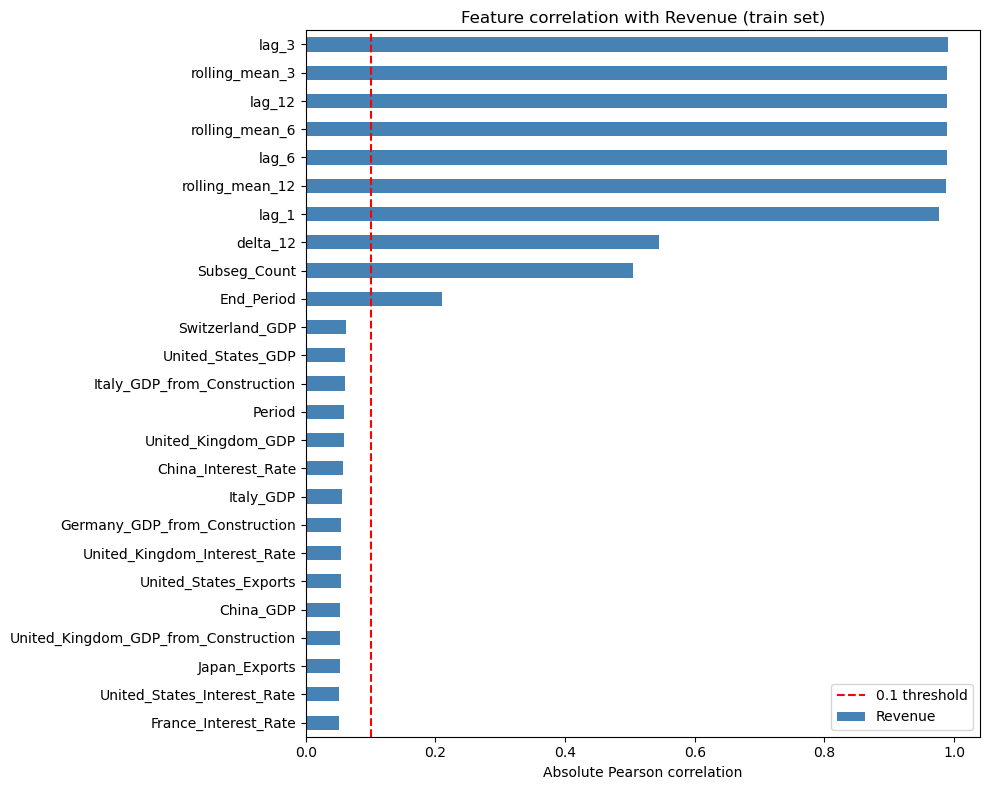


Features with correlation < 0.1: ['Switzerland_GDP', 'United_States_GDP', 'Italy_GDP_from_Construction', 'Period', 'United_Kingdom_GDP', 'China_Interest_Rate', 'Italy_GDP', 'Germany_GDP_from_Construction', 'United_Kingdom_Interest_Rate', 'United_States_Exports', 'China_GDP', 'United_Kingdom_GDP_from_Construction', 'Japan_Exports', 'United_States_Interest_Rate', 'France_Interest_Rate', 'Italy_Interest_Rate', 'Germany_Interest_Rate', 'Switzerland_Interest_Rate', 'Germany_GDP', 'United_States_Industrial_Production', 'France_Exports', 'Japan_GDP_from_Construction', 'Japan_GDP', 'Japan_GDP_from_Manufacturing', 'Switzerland_Industrial_Production', 'France_GDP', 'Japan_Inflation_Rate', 'delta_1', 'Germany_Industrial_Production', 'Germany_Exports', 'Italy_Exports', 'Italy_GDP_from_Manufacturing', 'Japan_Steel_Production', 'Japan_Core_Inflation_Rate', 'United_Kingdom_Exports', 'Japan_Industrial_Production', 'Italy_Industrial_Production', 'United_States_Steel_Production', 'United_Kingdom_Core_I

In [22]:
# ── filter method 2: correlation with target ──────────────────────────────────
# compute correlation of each feature with Revenue
# using X_train joined with y_train

train_with_target = X_train.copy()
train_with_target['Revenue'] = y_train.values

correlations = (
    train_with_target[numeric_cols + ['Revenue']]
    .corr()['Revenue']
    .drop('Revenue')
    .abs()
    .sort_values(ascending=False)
)

print("Feature correlation with Revenue (top 20):")
print(correlations.head(20).to_string())

# visualise
plt.figure(figsize=(10, 8))
correlations.head(25).plot(kind='barh', color='steelblue')
plt.axvline(0.1, color='red', linestyle='--', label='0.1 threshold')
plt.title('Feature correlation with Revenue (train set)')
plt.xlabel('Absolute Pearson correlation')
plt.gca().invert_yaxis()
plt.legend()
plt.tight_layout()
plt.show()

# flag low correlation features
low_corr_features = correlations[correlations < 0.1].index.tolist()
print(f"\nFeatures with correlation < 0.1: {low_corr_features}")

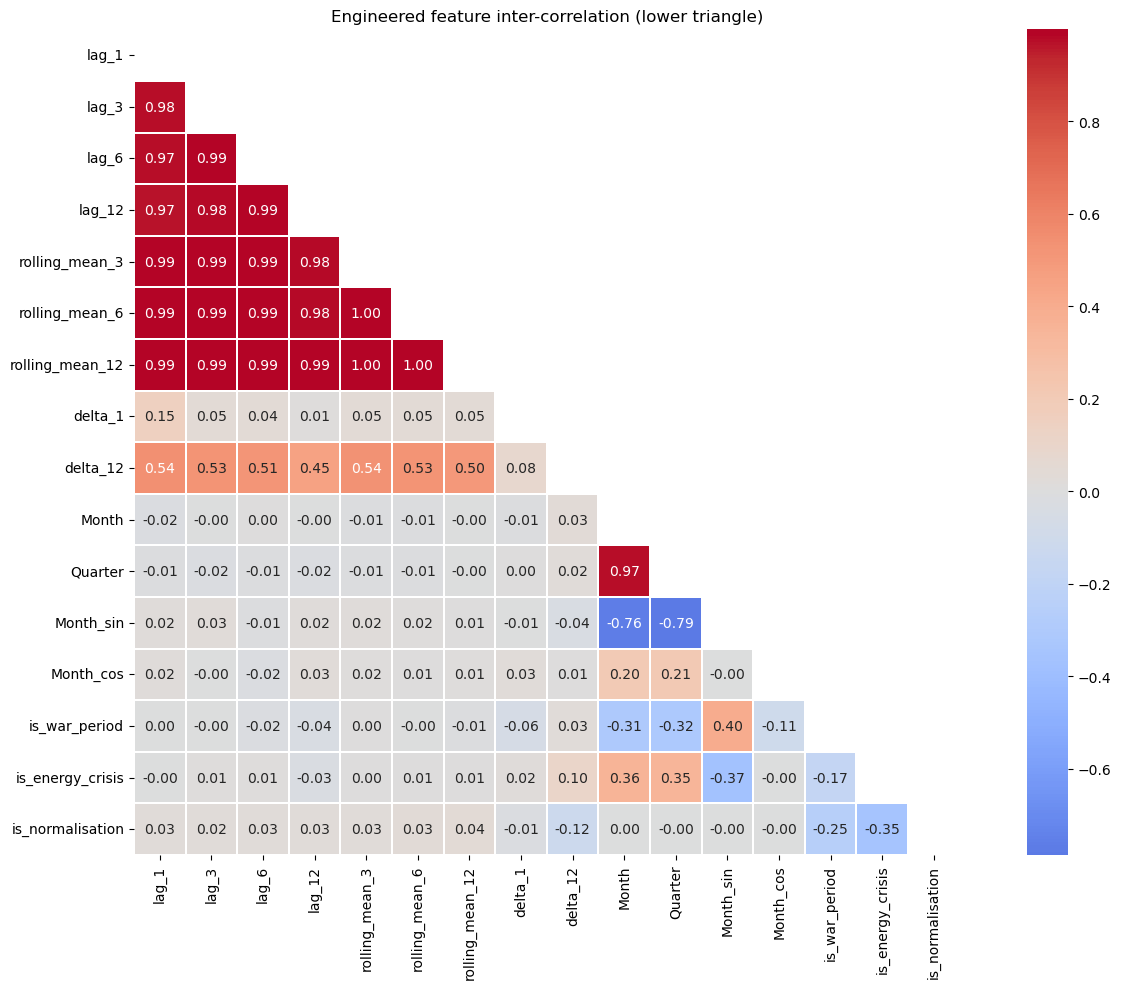

In [23]:
# ── filter method 3: multicollinearity check — engineered features ────────────
key_features = [c for c in numeric_cols if any(c.startswith(x) for x in
                ['lag', 'rolling', 'delta', 'Month', 'Quarter', 'trend',
                 'is_war', 'is_energy', 'is_normal', 'Month_sin', 'Month_cos'])]

corr_matrix = X_train[key_features].corr()

# create mask for upper triangle — shows only lower triangle
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(14, 10))
sns.heatmap(
    corr_matrix,
    mask=mask,
    cmap='coolwarm', center=0, annot=True, fmt='.2f',
    linewidths=0.3, square=True
)
plt.title('Engineered feature inter-correlation (lower triangle)')
plt.tight_layout()
plt.show()

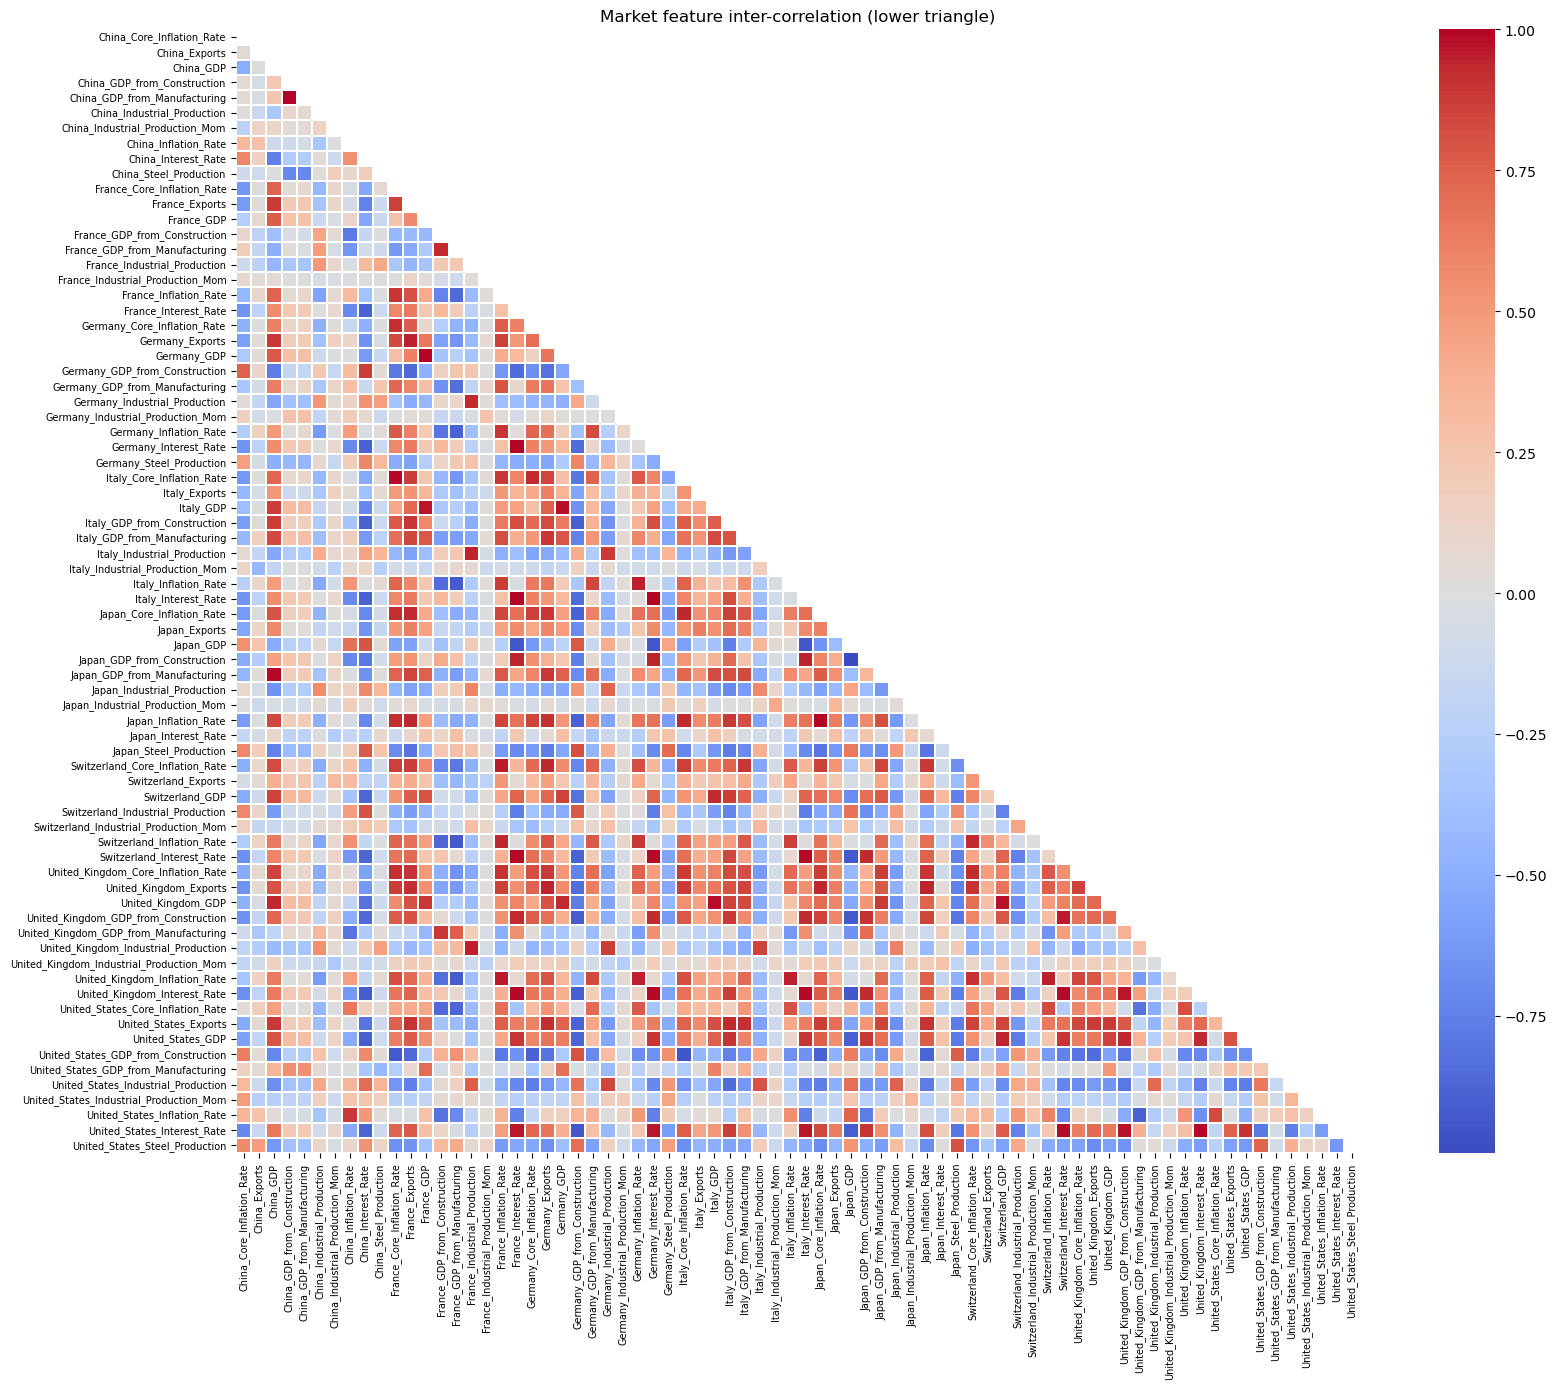

Highly correlated market pairs (>0.80): 266 pairs found
  China_GDP  vs  France_Exports:  0.876
  China_GDP  vs  Germany_Exports:  0.886
  China_GDP  vs  Italy_GDP:  0.868
  China_GDP  vs  Italy_GDP_from_Construction:  0.871
  China_GDP  vs  Italy_GDP_from_Manufacturing:  0.832
  China_GDP  vs  Japan_GDP_from_Manufacturing:  0.987
  China_GDP  vs  Japan_Inflation_Rate:  0.84
  China_GDP  vs  Switzerland_Core_Inflation_Rate:  0.823
  China_GDP  vs  Switzerland_GDP:  0.857
  China_GDP  vs  United_Kingdom_Core_Inflation_Rate:  0.858
  China_GDP  vs  United_Kingdom_GDP:  0.93
  China_GDP  vs  United_States_Exports:  0.887
  China_GDP_from_Construction  vs  China_GDP_from_Manufacturing:  0.998
  China_Inflation_Rate  vs  United_Kingdom_GDP_from_Manufacturing:  0.803
  China_Inflation_Rate  vs  United_States_Inflation_Rate:  0.886
  China_Interest_Rate  vs  France_Interest_Rate:  0.889
  China_Interest_Rate  vs  Germany_GDP_from_Construction:  0.873
  China_Interest_Rate  vs  Germany_Interes

In [24]:
# ── filter method 3b: multicollinearity check — market features ───────────────
market_feat_cols = [c for c in numeric_cols if any(c.startswith(x) for x in
                    ['Germany', 'France', 'China', 'Italy', 'Japan',
                     'Switzerland', 'United_Kingdom', 'United_States'])]

corr_market = X_train[market_feat_cols].corr()
mask_market = np.triu(np.ones_like(corr_market, dtype=bool))

plt.figure(figsize=(18, 14))
sns.heatmap(
    corr_market,
    mask=mask_market,
    cmap='coolwarm', center=0,
    linewidths=0.3, square=True,
    xticklabels=True, yticklabels=True
)
plt.title('Market feature inter-correlation (lower triangle)')
plt.xticks(fontsize=7, rotation=90)
plt.yticks(fontsize=7)
plt.tight_layout()
plt.show()

# identify highly correlated market pairs (>0.95)
high_corr_market = []
for i in range(len(market_feat_cols)):
    for j in range(i+1, len(market_feat_cols)):
        val = abs(corr_market.loc[market_feat_cols[i], market_feat_cols[j]])
        if val > 0.80:
            high_corr_market.append((market_feat_cols[i], market_feat_cols[j], round(val, 3)))

print(f"Highly correlated market pairs (>0.80): {len(high_corr_market)} pairs found")
for pair in high_corr_market:
    print(f"  {pair[0]}  vs  {pair[1]}:  {pair[2]}")

In [25]:
# keep only one representative per economic concept
# chosen based on relevance to Siemens (German company) and correlation with revenue from EDA

market_cols_to_keep = [
    'Germany_GDP',                    # economic size — representative of Europe
    'Germany_Interest_Rate',          # monetary policy — same for all Eurozone
    'Germany_Inflation_Rate',         # price pressure — representative of Europe  
    'Germany_Industrial_Production',  # industrial activity — most relevant for Siemens
    'Germany_Exports',                # trade activity
    'China_GDP',                      # China is a key Siemens market
    'United_States_GDP',              # US economic conditions
    'Japan_Steel_Production',         # industrial commodity proxy
    'United_States_Industrial_Production'  # global industrial activity
]

# drop all other market columns from X_train and X_val
all_market_cols = [c for c in X_train.columns if any(c.startswith(x) for x in
                   ['Germany', 'France', 'China', 'Italy', 'Japan',
                    'Switzerland', 'United_Kingdom', 'United_States'])]

market_cols_to_drop = [c for c in all_market_cols if c not in market_cols_to_keep]

X_train = X_train.drop(columns=market_cols_to_drop)
X_val   = X_val.drop(columns=market_cols_to_drop)

print(f"Dropped {len(market_cols_to_drop)} redundant market columns")
print(f"X_train shape after market reduction: {X_train.shape}")
print(f"Remaining market features: {market_cols_to_keep}")

Dropped 65 redundant market columns
X_train shape after market reduction: (864, 34)
Remaining market features: ['Germany_GDP', 'Germany_Interest_Rate', 'Germany_Inflation_Rate', 'Germany_Industrial_Production', 'Germany_Exports', 'China_GDP', 'United_States_GDP', 'Japan_Steel_Production', 'United_States_Industrial_Production']


#### 4.3.2. Embedded Methods

  File "c:\Users\nicol\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "c:\Users\nicol\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\nicol\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
                        pass_fds, cwd, env,
                        ^^^^^^^^^^^^^^^^^^^
    ...<5 lines>...
                        gid, gids, uid, umask,
                        ^^^^^^^^^^^^^^^^^^^^^^
                        start_new_session, process_group)
                        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\nicol\anaconda3\Lib\subprocess.

LightGBM feature importance (top 25):
lag_1                                  582
lag_3                                  432
Subseg_Count                           422
lag_6                                  377
Period                                 376
Germany_Exports                        358
rolling_mean_3                         334
delta_1                                325
lag_12                                 290
rolling_mean_12                        263
rolling_mean_6                         259
Germany_Industrial_Production          215
Germany_Inflation_Rate                 210
United_States_Industrial_Production    203
Month_sin                              200
Month                                  194
Month_cos                              191
End_Period                             191
delta_12                               175
Japan_Steel_Production                 152


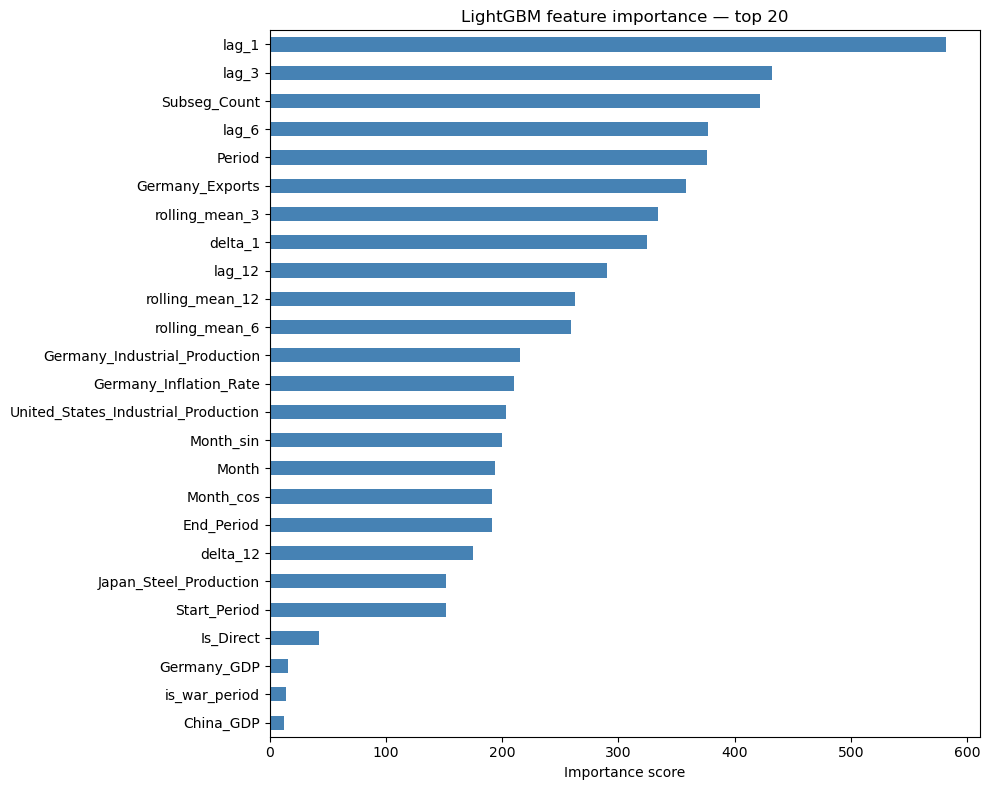


Features with zero importance (candidates to drop): ['United_States_GDP', 'Germany_Interest_Rate', 'Quarter']


In [26]:
# ── embedded method: lightgbm feature importance ──────────────────────────────
# train a quick lightgbm just to get feature importances
# this tells us which features the model actually finds useful
#!pip install lightgbm
import lightgbm as lgb

# drop non-numeric and identifier columns for this check
cols_to_drop = ['Date', 'Segment', 'Business_Unit', 'Subsegment', 'Biz_Desc']
cols_to_drop = [c for c in cols_to_drop if c in X_train.columns]

X_train_lgb = X_train.drop(columns=cols_to_drop)
X_val_lgb   = X_val.drop(columns=cols_to_drop)

# fill any remaining NaNs with median (only for importance check)
X_train_lgb = X_train_lgb.fillna(X_train_lgb.median())
X_val_lgb   = X_val_lgb.fillna(X_train_lgb.median())

model_fs = lgb.LGBMRegressor(n_estimators=200, random_state=42, verbose=-1)
model_fs.fit(X_train_lgb, y_train)

importance = pd.Series(
    model_fs.feature_importances_,
    index=X_train_lgb.columns
).sort_values(ascending=False)

print("LightGBM feature importance (top 25):")
print(importance.head(20).to_string())

plt.figure(figsize=(10, 8))
importance.head(25).plot(kind='barh', color='steelblue')
plt.title('LightGBM feature importance — top 20')
plt.xlabel('Importance score')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# flag features with zero importance
zero_importance = importance[importance == 0].index.tolist()
print(f"\nFeatures with zero importance (candidates to drop): {zero_importance}")

Random Forest feature importance (top 20):
rolling_mean_6                         0.363040
rolling_mean_12                        0.322661
rolling_mean_3                         0.213689
lag_3                                  0.050928
Subseg_Count                           0.014396
lag_6                                  0.010574
lag_1                                  0.009912
End_Period                             0.002363
Start_Period                           0.002161
lag_12                                 0.001499
Germany_Inflation_Rate                 0.001215
delta_1                                0.001113
Period                                 0.001040
Germany_Industrial_Production          0.001017
Month_sin                              0.000877
United_States_Industrial_Production    0.000844
Month_cos                              0.000705
Germany_Exports                        0.000493
Japan_Steel_Production                 0.000388
delta_12                               0.0003

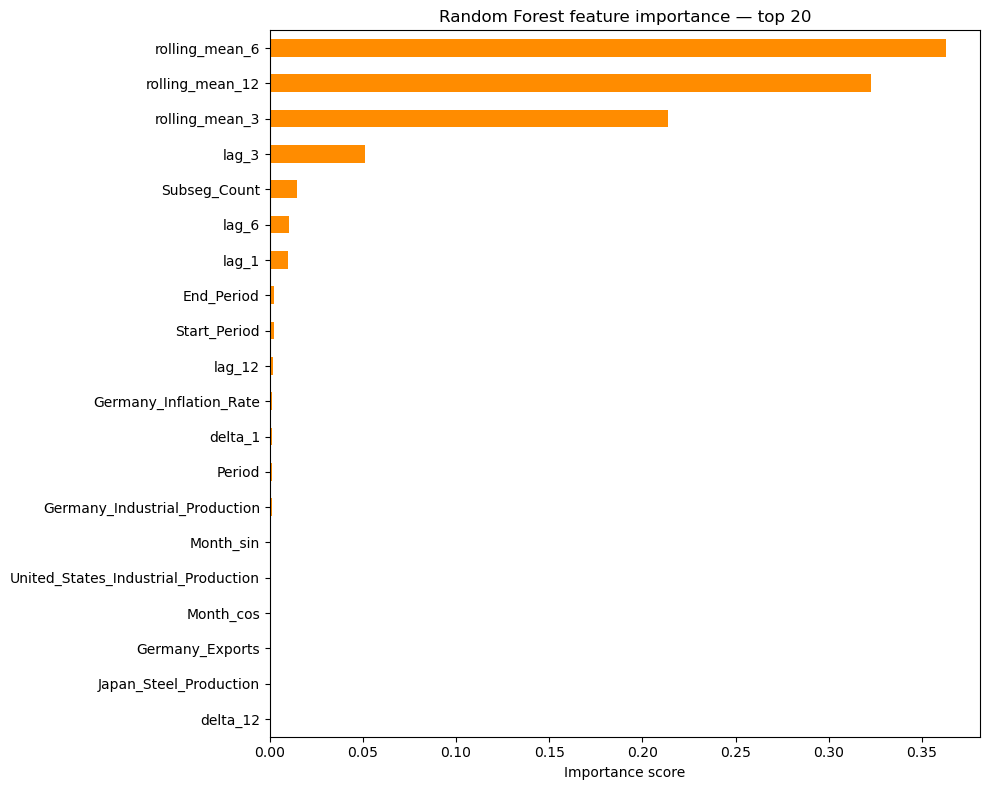

In [27]:
# ── embedded method 2: random forest feature importance ───────────────────────
from sklearn.ensemble import RandomForestRegressor

cols_to_drop_rf = ['Date', 'Segment', 'Business_Unit', 'Subsegment', 'Biz_Desc']
cols_to_drop_rf = [c for c in cols_to_drop_rf if c in X_train.columns]

X_train_rf = X_train.drop(columns=cols_to_drop_rf).copy()
X_train_rf = X_train_rf.fillna(-1)

model_rf = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
model_rf.fit(X_train_rf, y_train)

importance_rf = pd.Series(
    model_rf.feature_importances_,
    index=X_train_rf.columns
).sort_values(ascending=False)

print("Random Forest feature importance (top 20):")
print(importance_rf.head(20).to_string())

plt.figure(figsize=(10, 8))
importance_rf.head(20).plot(kind='barh', color='darkorange')
plt.title('Random Forest feature importance — top 20')
plt.xlabel('Importance score')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

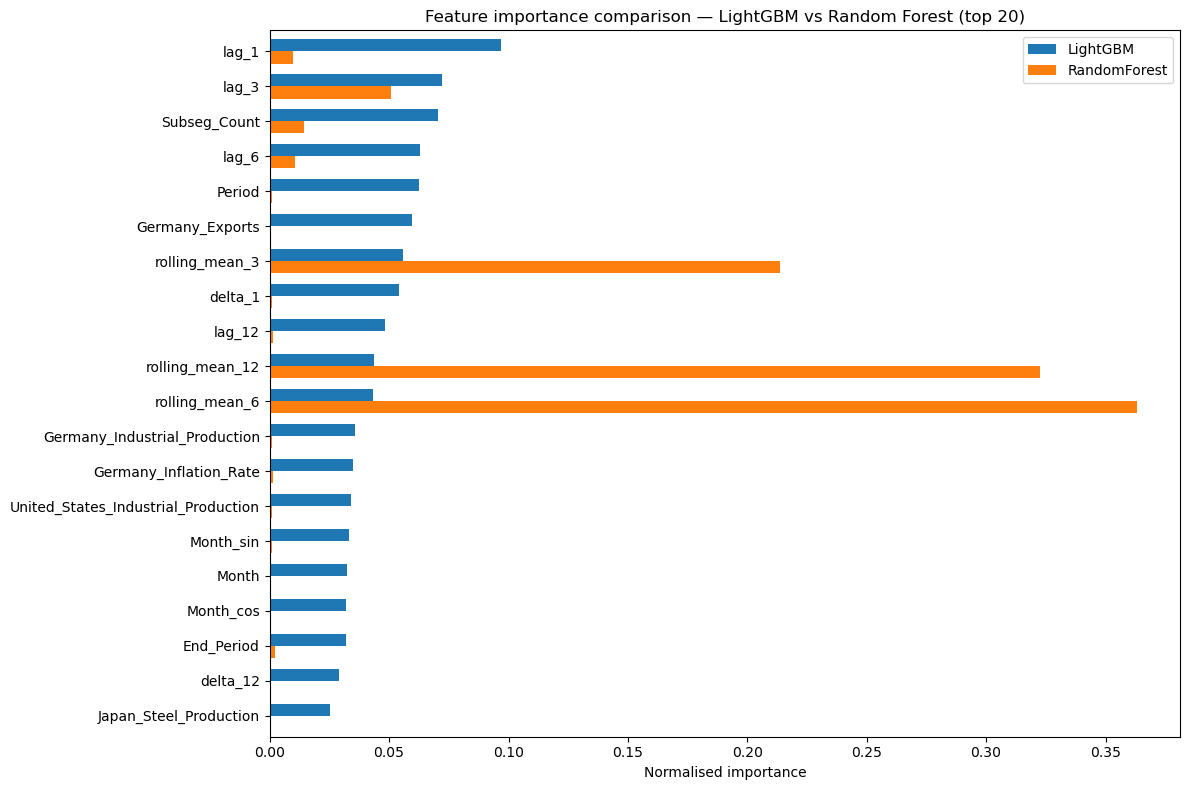


Features in top 15 of BOTH models (13 features):
  Germany_Industrial_Production
  Germany_Inflation_Rate
  Month_sin
  Period
  Subseg_Count
  delta_1
  lag_1
  lag_12
  lag_3
  lag_6
  rolling_mean_12
  rolling_mean_3
  rolling_mean_6


In [28]:
# ── compare LightGBM vs Random Forest importance ─────────────────────────────
# normalise both to 0-1 scale for fair comparison
importance_lgb_norm = importance / importance.sum()
importance_rf_norm  = importance_rf / importance_rf.sum()

comparison = pd.DataFrame({
    'LightGBM': importance_lgb_norm,
    'RandomForest': importance_rf_norm
}).fillna(0).sort_values('LightGBM', ascending=False).head(20)

comparison.plot(kind='barh', figsize=(12, 8), width=0.7)
plt.title('Feature importance comparison — LightGBM vs Random Forest (top 20)')
plt.xlabel('Normalised importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# features that both models agree are important (top 15 in both)
top_lgb = set(importance_lgb_norm.head(15).index)
top_rf  = set(importance_rf_norm.head(15).index)
agreed  = top_lgb & top_rf

print(f"\nFeatures in top 15 of BOTH models ({len(agreed)} features):")
for f in sorted(agreed):
    print(f"  {f}")

#### 4.3.3 Final insights

In [29]:
# normalize both importances
imp_lgb = importance / importance.sum()
imp_rf  = importance_rf / importance_rf.sum()

# align indexes
imp_df = pd.DataFrame({
    'lgb': imp_lgb,
    'rf': imp_rf
}).fillna(0)

# combined score
imp_df['combined'] = (imp_df['lgb'] + imp_df['rf']) / 2

imp_df = imp_df.sort_values(by='combined', ascending=False)

print(imp_df.head(20))

                                          lgb        rf  combined
rolling_mean_6                       0.043181  0.363040  0.203110
rolling_mean_12                      0.043848  0.322661  0.183254
rolling_mean_3                       0.055685  0.213689  0.134687
lag_3                                0.072024  0.050928  0.061476
lag_1                                0.097032  0.009912  0.053472
Subseg_Count                         0.070357  0.014396  0.042377
lag_6                                0.062854  0.010574  0.036714
Period                               0.062688  0.001040  0.031864
Germany_Exports                      0.059687  0.000493  0.030090
delta_1                              0.054185  0.001113  0.027649
lag_12                               0.048349  0.001499  0.024924
Germany_Industrial_Production        0.035845  0.001017  0.018431
Germany_Inflation_Rate               0.035012  0.001215  0.018113
United_States_Industrial_Production  0.033845  0.000844  0.017344
Month_sin 

In [30]:
imp_df['cumulative'] = imp_df['combined'].cumsum()

selected_features = imp_df[imp_df['cumulative'] <= 0.95].index.tolist()

print("Selected features:", selected_features)
print("Number of features:", len(selected_features))

Selected features: ['rolling_mean_6', 'rolling_mean_12', 'rolling_mean_3', 'lag_3', 'lag_1', 'Subseg_Count', 'lag_6', 'Period', 'Germany_Exports', 'delta_1', 'lag_12', 'Germany_Industrial_Production', 'Germany_Inflation_Rate', 'United_States_Industrial_Production', 'Month_sin', 'End_Period', 'Month_cos']
Number of features: 17


In [31]:
final_features = [
    # trend (cleaned)
    'rolling_mean_3',
    'rolling_mean_12',

    # dynamics
    'lag_1','lag_3','lag_6','lag_12',
    'delta_1','delta_12',

    # time structure
    'Period','Month_sin','Month_cos',

    # segmentation
    'Subseg_Count',

    # macro (best only)
    'Germany_Exports',
    'Germany_Industrial_Production',
    'Germany_Inflation_Rate',
    'United_States_Industrial_Production'
    
]

In [32]:
X_train_selected = X_train[final_features]
X_val_selected   = X_val[final_features]

In [33]:
X_train_selected.isna().sum()

rolling_mean_3                          24
rolling_mean_12                         24
lag_1                                   24
lag_3                                   72
lag_6                                  144
lag_12                                 288
delta_1                                 48
delta_12                               312
Period                                   0
Month_sin                                0
Month_cos                                0
Subseg_Count                             0
Germany_Exports                          0
Germany_Industrial_Production            0
Germany_Inflation_Rate                   0
United_States_Industrial_Production      0
dtype: int64

In [34]:
lag_cols = ['rolling_mean_3', 'rolling_mean_12', 'lag_1', 'lag_3',
            'lag_6', 'lag_12', 'delta_1', 'delta_12']

X_train_selected[lag_cols] = X_train_selected[lag_cols].fillna(0)
X_val_selected[lag_cols]   = X_val_selected[lag_cols].fillna(0)

print("Missing values after fill:")
print(X_train_selected.isna().sum())

Missing values after fill:
rolling_mean_3                         0
rolling_mean_12                        0
lag_1                                  0
lag_3                                  0
lag_6                                  0
lag_12                                 0
delta_1                                0
delta_12                               0
Period                                 0
Month_sin                              0
Month_cos                              0
Subseg_Count                           0
Germany_Exports                        0
Germany_Industrial_Production          0
Germany_Inflation_Rate                 0
United_States_Industrial_Production    0
dtype: int64


## 5. Modeling

### 5.1 ETS 

In [35]:
excluded_segments = ['SSI02796', 'SSI02798', 'SSI03798', 'SSI07098',
                     'SSI02792', 'SSI02793', 'SSI02799']

clean_segments = [s for s in seg_train['Segment'].unique()
                  if s not in excluded_segments]

In [36]:
# ── fit one ETS model per segment ─────────────────────────────────────────────
ets_forecasts = {}

for seg in clean_segments:
    train_data = (seg_train[seg_train['Segment'] == seg]
                  .sort_values('Period')['Revenue']
                  .values)

    if len(train_data) >= 24:
        model = ExponentialSmoothing(
            train_data, trend='add', seasonal='add', seasonal_periods=12)
    elif len(train_data) >= 12:
        model = ExponentialSmoothing(
            train_data, trend='add', seasonal='add', seasonal_periods=6)
    else:
        model = ExponentialSmoothing(
            train_data, trend='add', seasonal=None)

    fitted = model.fit(optimized=True)
    ets_forecasts[seg] = fitted.forecast(6)

print(f"ETS fitted for {len(ets_forecasts)} segments")

ETS fitted for 17 segments


In [37]:
# ── evaluate at segment level ─────────────────────────────────────────────────
val_periods = sorted(seg_val['Period'].unique())  # [37,38,39,40,41,42]

seg_results = []

for seg in clean_segments:
    actual    = (seg_val[seg_val['Segment'] == seg]
                 .sort_values('Period')['Revenue'].values)
    predicted = ets_forecasts[seg]
    min_len   = min(len(actual), len(predicted))

    if min_len == 0:
        continue

    actual    = actual[:min_len]
    predicted = predicted[:min_len]

    rmse = np.sqrt(mean_squared_error(actual, predicted))

    seg_results.append({
        'Segment':     seg,
        'RMSE':        rmse,
        'Actual_mean': np.mean(actual)
    })

seg_results_df = pd.DataFrame(seg_results)
seg_results_df['RMSE_pct'] = (seg_results_df['RMSE'] /
                               seg_results_df['Actual_mean'] * 100)

seg_clean = seg_results_df[seg_results_df['Actual_mean'] > 0]

print("=== ETS — Segment Level ===")
print(seg_clean[['Segment','RMSE','Actual_mean','RMSE_pct']]
      .sort_values('RMSE_pct', ascending=False).to_string())
print(f"\nMean RMSE:              {seg_clean['RMSE'].mean():,.0f}")
print(f"Median RMSE%:           {seg_clean['RMSE_pct'].median():.2f}%")
print(f"Revenue-weighted RMSE%: {(seg_clean['RMSE']/seg_clean['Actual_mean']).mean()*100:.2f}%")

=== ETS — Segment Level ===
     Segment          RMSE   Actual_mean   RMSE_pct
12  SSI04799  3.089558e+06  3.198620e+06  96.590342
0   SSI02710  5.384244e+05  1.041894e+06  51.677448
11  SSI04784  6.198603e+06  1.521818e+07  40.731575
8   SSI03799  1.386289e+06  4.759295e+06  29.128026
14  SSI07082  7.659755e+06  3.379684e+07  22.664116
15  SSI07083  1.740219e+06  7.739924e+06  22.483666
13  SSI07081  5.788913e+06  3.727653e+07  15.529645
4   SSI02786  1.194690e+07  8.173080e+07  14.617373
5   SSI03781  2.535352e+07  3.413729e+08   7.426929
7   SSI03784  3.588833e+06  5.666469e+07   6.333455
10  SSI04783  1.441580e+07  2.546508e+08   5.661006
6   SSI03782  5.079999e+07  1.010808e+09   5.025683
9   SSI04781  4.758819e+07  1.041583e+09   4.568832
1   SSI02780  1.316057e+07  3.471205e+08   3.791355
2   SSI02782  1.122696e+07  3.364127e+08   3.337258
3   SSI02784  1.496903e+07  4.785124e+08   3.128243

Mean RMSE:              13,715,722
Median RMSE%:           11.02%
Revenue-weighted RMSE

In [38]:
# ── upward aggregation: segment → business unit ───────────────────────────────
# map each segment to its BU using training data
seg_to_bu = (seg_train[['Segment', 'Business_Unit']]
             .drop_duplicates()
             .set_index('Segment')['Business_Unit'])

# build forecast dataframe at segment level (period x segment)
seg_fc_df = pd.DataFrame({
    seg: ets_forecasts[seg] for seg in clean_segments
}, index=val_periods).T  # shape: (n_segments, 6)

seg_fc_df['Business_Unit'] = seg_fc_df.index.map(seg_to_bu)

# sum segments within each BU
bu_fc_df = seg_fc_df.groupby('Business_Unit')[val_periods].sum()

# actual BU revenue in validation
bu_actual = (df_merged[df_merged['Period'].isin(val_periods)]
             .groupby(['Business_Unit', 'Period'])['Revenue']
             .sum()
             .unstack('Period'))

print("=== ETS — Business Unit Level ===")
bu_results = []
for bu in bu_fc_df.index:
    if bu not in bu_actual.index:
        continue
    actual    = bu_actual.loc[bu, val_periods].values
    predicted = bu_fc_df.loc[bu, val_periods].values
    rmse      = np.sqrt(mean_squared_error(actual, predicted))
    bu_results.append({
        'Business_Unit': bu,
        'RMSE':          rmse,
        'Actual_mean':   np.mean(actual)
    })

bu_results_df = pd.DataFrame(bu_results)
bu_results_df['RMSE_pct'] = (bu_results_df['RMSE'] /
                              bu_results_df['Actual_mean'] * 100)

print(bu_results_df[['Business_Unit','RMSE','Actual_mean','RMSE_pct']]
      .sort_values('RMSE_pct', ascending=False).to_string())
print(f"\nMean RMSE:    {bu_results_df['RMSE'].mean():,.0f}")
print(f"Median RMSE%: {bu_results_df['RMSE_pct'].median():.2f}%")

=== ETS — Business Unit Level ===
  Business_Unit          RMSE   Actual_mean  RMSE_pct
3        SSI070  7.793614e+06  7.881330e+07  9.888704
2        SSI047  6.148187e+07  1.314651e+09  4.676669
1        SSI037  4.774772e+07  1.413605e+09  3.377728
0        SSI027  2.489383e+07  1.244851e+09  1.999744

Mean RMSE:    35,479,257
Median RMSE%: 4.03%


In [39]:
# ── downward distribution: segment → subsegment ───────────────────────────────
# compute average quota per subsegment within each segment
# use training data only, clip negatives for quota stability
df_train_sub = df_merged[
    (df_merged['Period'] <= 36) &
    (~df_merged['Segment'].isin(excluded_segments))
].copy()

df_train_sub['Revenue_clipped'] = df_train_sub['Revenue'].clip(lower=0)

seg_totals = (df_train_sub.groupby(['Period', 'Segment'])['Revenue_clipped']
              .sum().reset_index()
              .rename(columns={'Revenue_clipped': 'Seg_Total'}))

df_train_sub = df_train_sub.merge(seg_totals, on=['Period', 'Segment'])

df_train_sub['Quota'] = np.where(
    df_train_sub['Seg_Total'] > 0,
    df_train_sub['Revenue_clipped'] / df_train_sub['Seg_Total'],
    0
)

avg_quota = (df_train_sub.groupby(['Segment', 'Subsegment'])['Quota']
             .mean().reset_index()
             .rename(columns={'Quota': 'Avg_Quota'}))

# distribute segment forecasts to subsegments
subseg_fc_rows = []

for seg in clean_segments:
    seg_fc     = ets_forecasts[seg]
    seg_quotas = avg_quota[avg_quota['Segment'] == seg]

    for _, row in seg_quotas.iterrows():
        for i, period in enumerate(val_periods):
            subseg_fc_rows.append({
                'Period':       period,
                'Business_Unit': seg_to_bu.get(seg),
                'Segment':      seg,
                'Subsegment':   row['Subsegment'],
                'Revenue':      seg_fc[i] * row['Avg_Quota']
            })

subseg_fc_df = pd.DataFrame(subseg_fc_rows)
print(f"Subsegment forecasts shape: {subseg_fc_df.shape}")
print(subseg_fc_df.head(10))

Subsegment forecasts shape: (762, 5)
   Period Business_Unit   Segment  Subsegment       Revenue
0      37        SSI027  SSI02710    SSI02710  7.076579e+05
1      38        SSI027  SSI02710    SSI02710  7.455288e+05
2      39        SSI027  SSI02710    SSI02710  7.572081e+05
3      40        SSI027  SSI02710    SSI02710  7.699049e+05
4      41        SSI027  SSI02710    SSI02710  8.118040e+05
5      42        SSI027  SSI02710    SSI02710  1.368301e+06
6      37        SSI027  SSI02710  SSI0271002  1.833679e+05
7      38        SSI027  SSI02710  SSI0271002  1.931810e+05
8      39        SSI027  SSI02710  SSI0271002  1.962073e+05
9      40        SSI027  SSI02710  SSI0271002  1.994973e+05


In [40]:
# ── evaluate at subsegment level ──────────────────────────────────────────────
subseg_actual = (df_merged[df_merged['Period'].isin(val_periods)]
                 .groupby(['Subsegment', 'Period'])['Revenue']
                 .sum().reset_index())

subseg_eval = subseg_fc_df.merge(
    subseg_actual.rename(columns={'Revenue': 'Actual'}),
    on=['Subsegment', 'Period'], how='inner'
)

subseg_results = []
for sub in subseg_eval['Subsegment'].unique():
    d         = subseg_eval[subseg_eval['Subsegment'] == sub]
    actual    = d['Actual'].values
    predicted = d['Revenue'].values
    if len(actual) == 0 or np.mean(actual) == 0:
        continue
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    subseg_results.append({
        'Subsegment':  sub,
        'RMSE':        rmse,
        'Actual_mean': np.mean(actual)
    })

subseg_results_df = pd.DataFrame(subseg_results)
subseg_results_df['RMSE_pct'] = (subseg_results_df['RMSE'] /
                                  subseg_results_df['Actual_mean'] * 100)

print("=== ETS — Subsegment Level ===")
print(f"Mean RMSE:    {subseg_results_df['RMSE'].mean():,.0f}")
print(f"Median RMSE%: {subseg_results_df['RMSE_pct'].median():.2f}%")

=== ETS — Subsegment Level ===
Mean RMSE:    6,831,176
Median RMSE%: 30.26%


In [41]:
# ── summary across all three levels ──────────────────────────────────────────
print("=" * 50)
print("ETS MIDDLE-OUT — SUMMARY")
print("=" * 50)
print(f"Segment level   — Median RMSE%: {seg_clean['RMSE_pct'].median():.2f}%")
print(f"Business Unit   — Median RMSE%: {bu_results_df['RMSE_pct'].median():.2f}%")
print(f"Subsegment      — Median RMSE%: {subseg_results_df['RMSE_pct'].median():.2f}%")

ETS MIDDLE-OUT — SUMMARY
Segment level   — Median RMSE%: 11.02%
Business Unit   — Median RMSE%: 4.03%
Subsegment      — Median RMSE%: 30.26%


### 5.2 LightGBM

In [42]:
X_train_selected.dtypes

rolling_mean_3                         float64
rolling_mean_12                        float64
lag_1                                  float64
lag_3                                  float64
lag_6                                  float64
lag_12                                 float64
delta_1                                float64
delta_12                               float64
Period                                   int64
Month_sin                              float64
Month_cos                              float64
Subseg_Count                             int64
Germany_Exports                        float64
Germany_Industrial_Production          float64
Germany_Inflation_Rate                 float64
United_States_Industrial_Production    float64
dtype: object

In [43]:
"""
# ── 1. Keep Period as metadata, not a model feature ───────────────────────────
# Period was dropped from X_train_selected during feature selection, but we
# need it for sorting/filtering at predict time. Keep a separate copy.
meta_train = X_train[['Segment', 'Period']].copy()
meta_val   = X_val[['Segment', 'Period']].copy()

# ── 2. Fix Date: convert to integer days (numeric time signal) ────────────────
date_min = X_train_selected['Date'].min()

X_train_selected = X_train_selected.copy()
X_val_selected   = X_val_selected.copy()

X_train_selected['time_index'] = (X_train_selected['Date'] - date_min).dt.days
X_val_selected['time_index']   = (X_val_selected['Date']   - date_min).dt.days

X_train_selected = X_train_selected.drop(columns=['Date'])
X_val_selected   = X_val_selected.drop(columns=['Date'])

# ── 3. Fix categoricals: cast to pandas 'category' dtype ─────────────────────
cat_cols = [c for c in ['Segment', 'Business_Unit', 'Subsegment']
            if c in X_train_selected.columns]

for col in cat_cols:
    X_train_selected[col] = X_train_selected[col].astype('category')
    X_val_selected[col]   = X_val_selected[col].astype('category')
"""

"\n# ── 1. Keep Period as metadata, not a model feature ───────────────────────────\n# Period was dropped from X_train_selected during feature selection, but we\n# need it for sorting/filtering at predict time. Keep a separate copy.\nmeta_train = X_train[['Segment', 'Period']].copy()\nmeta_val   = X_val[['Segment', 'Period']].copy()\n\n# ── 2. Fix Date: convert to integer days (numeric time signal) ────────────────\ndate_min = X_train_selected['Date'].min()\n\nX_train_selected = X_train_selected.copy()\nX_val_selected   = X_val_selected.copy()\n\nX_train_selected['time_index'] = (X_train_selected['Date'] - date_min).dt.days\nX_val_selected['time_index']   = (X_val_selected['Date']   - date_min).dt.days\n\nX_train_selected = X_train_selected.drop(columns=['Date'])\nX_val_selected   = X_val_selected.drop(columns=['Date'])\n\n# ── 3. Fix categoricals: cast to pandas 'category' dtype ─────────────────────\ncat_cols = [c for c in ['Segment', 'Business_Unit', 'Subsegment']\n            if c 

In [44]:
# ── fit LightGBM ──────────────────────────────────────────────────────────────
feature_cols = X_train_selected.columns.tolist()

lgbm_model = lgb.LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=31,
    min_child_samples=5,
    random_state=42,
    verbosity=-1
)

lgbm_model.fit(X_train_selected, y_train)

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.05
,n_estimators,500
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,5


In [45]:
# ── segment level predictions ─────────────────────────────────────────────────
lgbm_forecasts = {}

for seg in clean_segments:
    # Use meta_val to filter+sort by Period (not X_val_selected, which has no Period)
    seg_idx  = X_val[X_val['Segment'] == seg].sort_values('Period').index
    val_rows = X_val_selected.loc[seg_idx]

    if len(val_rows) == 0:
        continue

    lgbm_forecasts[seg] = lgbm_model.predict(val_rows[feature_cols])

# ── segment level evaluation ──────────────────────────────────────────────────
seg_results_lgbm = []

for seg in clean_segments:
    actual    = seg_val[seg_val['Segment'] == seg].sort_values('Period')['Revenue'].values
    predicted = lgbm_forecasts.get(seg, np.array([]))
    min_len   = min(len(actual), len(predicted))
    if min_len == 0:
        continue
    rmse = np.sqrt(mean_squared_error(actual[:min_len], predicted[:min_len]))
    seg_results_lgbm.append({
        'Segment':     seg,
        'RMSE':        rmse,
        'Actual_mean': np.mean(actual[:min_len])
    })

seg_lgbm_df = pd.DataFrame(seg_results_lgbm)
seg_lgbm_df['RMSE_pct'] = seg_lgbm_df['RMSE'] / seg_lgbm_df['Actual_mean'] * 100
seg_lgbm_clean = seg_lgbm_df[seg_lgbm_df['Actual_mean'] > 0]

print("=== LightGBM — Segment Level ===")
print(seg_lgbm_clean[['Segment', 'RMSE', 'Actual_mean', 'RMSE_pct']]
      .sort_values('RMSE_pct', ascending=False).to_string())
print(f"\nMean RMSE:              {seg_lgbm_clean['RMSE'].mean():,.0f}")
print(f"Median RMSE%:           {seg_lgbm_clean['RMSE_pct'].median():.2f}%")
print(f"Revenue-weighted RMSE%: {(seg_lgbm_clean['RMSE']/seg_lgbm_clean['Actual_mean']).mean()*100:.2f}%")

=== LightGBM — Segment Level ===
     Segment          RMSE   Actual_mean   RMSE_pct
0   SSI02710  8.858273e+05  1.041894e+06  85.020837
12  SSI04799  1.809194e+06  3.198620e+06  56.561718
8   SSI03799  2.517172e+06  4.759295e+06  52.889603
11  SSI04784  6.154798e+06  1.521818e+07  40.443730
7   SSI03784  2.063895e+07  5.666469e+07  36.422942
13  SSI07081  9.513558e+06  3.727653e+07  25.521574
14  SSI07082  8.383265e+06  3.379684e+07  24.804879
4   SSI02786  1.725205e+07  8.173080e+07  21.108380
3   SSI02784  5.573961e+07  4.785124e+08  11.648521
6   SSI03782  1.125933e+08  1.010808e+09  11.138940
15  SSI07083  8.532924e+05  7.739924e+06  11.024557
2   SSI02782  3.068857e+07  3.364127e+08   9.122296
10  SSI04783  1.957039e+07  2.546508e+08   7.685188
9   SSI04781  7.398813e+07  1.041583e+09   7.103431
1   SSI02780  2.431739e+07  3.471205e+08   7.005461
5   SSI03781  2.068487e+07  3.413729e+08   6.059318

Mean RMSE:              25,349,396
Median RMSE%:           16.38%
Revenue-weighted

In [46]:
# ── upward: segment → business unit ──────────────────────────────────────────
bu_fc_lgbm = {}

for seg, fc in lgbm_forecasts.items():
    bu = seg_to_bu.get(seg)
    if bu not in bu_fc_lgbm:
        bu_fc_lgbm[bu] = np.zeros(6)
    bu_fc_lgbm[bu] += fc

bu_results_lgbm = []

for bu, predicted in bu_fc_lgbm.items():
    actual = (df_merged[df_merged['Period'].isin(val_periods)]
              .groupby('Business_Unit')['Revenue']
              .sum()
              .get(bu, None))
    actual = (df_merged[(df_merged['Period'].isin(val_periods)) &
                        (df_merged['Business_Unit'] == bu)]
              .groupby('Period')['Revenue'].sum().values)
    if len(actual) == 0:
        continue
    rmse = np.sqrt(mean_squared_error(actual, predicted[:len(actual)]))
    bu_results_lgbm.append({
        'Business_Unit': bu,
        'RMSE':          rmse,
        'Actual_mean':   np.mean(actual)
    })

bu_lgbm_df = pd.DataFrame(bu_results_lgbm)
bu_lgbm_df['RMSE_pct'] = bu_lgbm_df['RMSE'] / bu_lgbm_df['Actual_mean'] * 100

print("=== LightGBM — Business Unit Level ===")
print(bu_lgbm_df[['Business_Unit', 'RMSE', 'Actual_mean', 'RMSE_pct']]
      .sort_values('RMSE_pct', ascending=False).to_string())
print(f"\nMean RMSE:    {bu_lgbm_df['RMSE'].mean():,.0f}")
print(f"Median RMSE%: {bu_lgbm_df['RMSE_pct'].median():.2f}%")

=== LightGBM — Business Unit Level ===
  Business_Unit          RMSE   Actual_mean   RMSE_pct
3        SSI070  1.177904e+07  7.881330e+07  14.945500
1        SSI037  1.353235e+08  1.413605e+09   9.572938
0        SSI027  8.849680e+07  1.244851e+09   7.109029
2        SSI047  8.668859e+07  1.314651e+09   6.594040

Mean RMSE:    80,571,983
Median RMSE%: 8.34%


In [47]:
# ── downward: segment → subsegment (reuse same avg_quota from ETS) ────────────
subseg_fc_lgbm = []

for seg in clean_segments:
    if seg not in lgbm_forecasts:
        continue
    seg_fc     = lgbm_forecasts[seg]
    seg_quotas = avg_quota[avg_quota['Segment'] == seg]
    for _, row in seg_quotas.iterrows():
        for i, period in enumerate(val_periods):
            subseg_fc_lgbm.append({
                'Period':        period,
                'Business_Unit': seg_to_bu.get(seg),
                'Segment':       seg,
                'Subsegment':    row['Subsegment'],
                'Revenue':       seg_fc[i] * row['Avg_Quota']
            })

subseg_fc_lgbm_df = pd.DataFrame(subseg_fc_lgbm)

subseg_eval_lgbm = subseg_fc_lgbm_df.merge(
    subseg_actual.rename(columns={'Revenue': 'Actual'}),
    on=['Subsegment', 'Period'], how='inner'
)

subseg_results_lgbm = []
for sub in subseg_eval_lgbm['Subsegment'].unique():
    d = subseg_eval_lgbm[subseg_eval_lgbm['Subsegment'] == sub]
    if np.mean(d['Actual'].values) == 0:
        continue
    rmse = np.sqrt(mean_squared_error(d['Actual'].values, d['Revenue'].values))
    subseg_results_lgbm.append({
        'Subsegment':  sub,
        'RMSE':        rmse,
        'Actual_mean': np.mean(d['Actual'].values)
    })

subseg_lgbm_df = pd.DataFrame(subseg_results_lgbm)
subseg_lgbm_df['RMSE_pct'] = subseg_lgbm_df['RMSE'] / subseg_lgbm_df['Actual_mean'] * 100

print("=== LightGBM — Subsegment Level ===")
print(f"Mean RMSE:    {subseg_lgbm_df['RMSE'].mean():,.0f}")
print(f"Median RMSE%: {subseg_lgbm_df['RMSE_pct'].median():.2f}%")

=== LightGBM — Subsegment Level ===
Mean RMSE:    7,692,610
Median RMSE%: 34.96%


In [48]:
# ── final comparison ──────────────────────────────────────────────────────────
print("=" * 47)
print("COMPARISON — ETS vs LightGBM")
print("=" * 47)
print(f"{'Level':<20} {'ETS':>10} {'LightGBM':>12}")
print("-" * 45)
print(f"{'Segment (Median%)':<20} {seg_clean['RMSE_pct'].median():>9.2f}% {seg_lgbm_clean['RMSE_pct'].median():>11.2f}%")
print(f"{'Business Unit (Median%)':<20} {bu_results_df['RMSE_pct'].median():>6.2f}% {bu_lgbm_df['RMSE_pct'].median():>11.2f}%")
print(f"{'Subsegment (Median%)':<20} {subseg_results_df['RMSE_pct'].median():>9.2f}% {subseg_lgbm_df['RMSE_pct'].median():>11.2f}%")

COMPARISON — ETS vs LightGBM
Level                       ETS     LightGBM
---------------------------------------------
Segment (Median%)        11.02%       16.38%
Business Unit (Median%)   4.03%        8.34%
Subsegment (Median%)     30.26%       34.96%


In [49]:
rf_model = RandomForestRegressor(
    n_estimators=500,
    max_depth=6,
    min_samples_leaf=5,
    random_state=42
)

rf_model.fit(X_train_selected, y_train)

rf_forecasts = {}
for seg in clean_segments:
    val_rows = X_val[X_val['Segment'] == seg].sort_values('Period')
    if len(val_rows) == 0:
        continue
    rf_forecasts[seg] = rf_model.predict(val_rows[final_features])

In [50]:
# ── segment level evaluation ──────────────────────────────────────────────────
seg_results_rf = []

for seg in clean_segments:
    actual    = seg_val[seg_val['Segment'] == seg].sort_values('Period')['Revenue'].values
    predicted = rf_forecasts.get(seg, np.array([]))
    min_len   = min(len(actual), len(predicted))
    if min_len == 0:
        continue
    rmse = np.sqrt(mean_squared_error(actual[:min_len], predicted[:min_len]))
    seg_results_rf.append({
        'Segment':     seg,
        'RMSE':        rmse,
        'Actual_mean': np.mean(actual[:min_len])
    })

seg_rf_df    = pd.DataFrame(seg_results_rf)
seg_rf_df['RMSE_pct'] = seg_rf_df['RMSE'] / seg_rf_df['Actual_mean'] * 100
seg_rf_clean = seg_rf_df[seg_rf_df['Actual_mean'] > 0]

print("=== Random Forest — Segment Level ===")
print(seg_rf_clean[['Segment', 'RMSE', 'Actual_mean', 'RMSE_pct']]
      .sort_values('RMSE_pct', ascending=False).to_string())
print(f"\nMean RMSE:              {seg_rf_clean['RMSE'].mean():,.0f}")
print(f"Median RMSE%:           {seg_rf_clean['RMSE_pct'].median():.2f}%")
print(f"Revenue-weighted RMSE%: {(seg_rf_clean['RMSE']/seg_rf_clean['Actual_mean']).mean()*100:.2f}%")

=== Random Forest — Segment Level ===
     Segment          RMSE   Actual_mean     RMSE_pct
0   SSI02710  1.124986e+07  1.041894e+06  1079.750660
8   SSI03799  3.408175e+06  4.759295e+06    71.610937
11  SSI04784  1.039199e+07  1.521818e+07    68.286691
12  SSI04799  1.963821e+06  3.198620e+06    61.395893
13  SSI07081  1.818031e+07  3.727653e+07    48.771465
4   SSI02786  2.753287e+07  8.173080e+07    33.687265
7   SSI03784  1.482479e+07  5.666469e+07    26.162313
14  SSI07082  7.821797e+06  3.379684e+07    23.143575
3   SSI02784  7.949627e+07  4.785124e+08    16.613212
15  SSI07083  1.200110e+06  7.739924e+06    15.505447
6   SSI03782  1.334469e+08  1.010808e+09    13.202001
2   SSI02782  3.491539e+07  3.364127e+08    10.378737
10  SSI04783  1.841751e+07  2.546508e+08     7.232458
5   SSI03781  2.167507e+07  3.413729e+08     6.349383
9   SSI04781  5.716495e+07  1.041583e+09     5.488275
1   SSI02780  1.841696e+07  3.471205e+08     5.305638

Mean RMSE:              28,756,671
Median R

In [51]:
# ── upward: segment → business unit ──────────────────────────────────────────
bu_fc_rf = {}

for seg, fc in rf_forecasts.items():
    bu = seg_to_bu.get(seg)
    if bu not in bu_fc_rf:
        bu_fc_rf[bu] = np.zeros(6)
    bu_fc_rf[bu] += fc

bu_results_rf = []

for bu, predicted in bu_fc_rf.items():
    actual = (df_merged[(df_merged['Period'].isin(val_periods)) &
                        (df_merged['Business_Unit'] == bu)]
              .groupby('Period')['Revenue'].sum().values)
    if len(actual) == 0:
        continue
    rmse = np.sqrt(mean_squared_error(actual, predicted[:len(actual)]))
    bu_results_rf.append({
        'Business_Unit': bu,
        'RMSE':          rmse,
        'Actual_mean':   np.mean(actual)
    })

bu_rf_df = pd.DataFrame(bu_results_rf)
bu_rf_df['RMSE_pct'] = bu_rf_df['RMSE'] / bu_rf_df['Actual_mean'] * 100

print("=== Random Forest — Business Unit Level ===")
print(bu_rf_df[['Business_Unit', 'RMSE', 'Actual_mean', 'RMSE_pct']]
      .sort_values('RMSE_pct', ascending=False).to_string())
print(f"\nMean RMSE:    {bu_rf_df['RMSE'].mean():,.0f}")
print(f"Median RMSE%: {bu_rf_df['RMSE_pct'].median():.2f}%")

=== Random Forest — Business Unit Level ===
  Business_Unit          RMSE   Actual_mean   RMSE_pct
3        SSI070  2.624668e+07  7.881330e+07  33.302345
1        SSI037  1.643247e+08  1.413605e+09  11.624515
0        SSI027  1.305247e+08  1.244851e+09  10.485166
2        SSI047  7.563560e+07  1.314651e+09   5.753285

Mean RMSE:    99,182,906
Median RMSE%: 11.05%


In [52]:
# ── downward: segment → subsegment ───────────────────────────────────────────
subseg_fc_rf = []

for seg in clean_segments:
    if seg not in rf_forecasts:
        continue
    seg_fc     = rf_forecasts[seg]
    seg_quotas = avg_quota[avg_quota['Segment'] == seg]
    for _, row in seg_quotas.iterrows():
        for i, period in enumerate(val_periods):
            subseg_fc_rf.append({
                'Period':        period,
                'Business_Unit': seg_to_bu.get(seg),
                'Segment':       seg,
                'Subsegment':    row['Subsegment'],
                'Revenue':       seg_fc[i] * row['Avg_Quota']
            })

subseg_fc_rf_df = pd.DataFrame(subseg_fc_rf)

subseg_eval_rf = subseg_fc_rf_df.merge(
    subseg_actual.rename(columns={'Revenue': 'Actual'}),
    on=['Subsegment', 'Period'], how='inner'
)

subseg_results_rf = []
for sub in subseg_eval_rf['Subsegment'].unique():
    d = subseg_eval_rf[subseg_eval_rf['Subsegment'] == sub]
    if np.mean(d['Actual'].values) == 0:
        continue
    rmse = np.sqrt(mean_squared_error(d['Actual'].values, d['Revenue'].values))
    subseg_results_rf.append({
        'Subsegment':  sub,
        'RMSE':        rmse,
        'Actual_mean': np.mean(d['Actual'].values)
    })

subseg_rf_df = pd.DataFrame(subseg_results_rf)
subseg_rf_df['RMSE_pct'] = subseg_rf_df['RMSE'] / subseg_rf_df['Actual_mean'] * 100

print("=== Random Forest — Subsegment Level ===")
print(f"Mean RMSE:    {subseg_rf_df['RMSE'].mean():,.0f}")
print(f"Median RMSE%: {subseg_rf_df['RMSE_pct'].median():.2f}%")

=== Random Forest — Subsegment Level ===
Mean RMSE:    7,999,870
Median RMSE%: 34.49%


In [53]:
# ── updated comparison including random forest ────────────────────────────────
print("=" * 60)
print("COMPARISON — ETS vs LightGBM vs Random Forest")
print("=" * 60)
print(f"{'Level':<22} {'ETS':>8} {'LightGBM':>10} {'RF':>8}")
print("-" * 55)
print(f"{'Segment (Median%)':<22} "
      f"{seg_clean['RMSE_pct'].median():>7.2f}% "
      f"{seg_lgbm_clean['RMSE_pct'].median():>9.2f}% "
      f"{seg_rf_clean['RMSE_pct'].median():>7.2f}%")
print(f"{'Business Unit (Med%)':<22} "
      f"{bu_results_df['RMSE_pct'].median():>7.2f}% "
      f"{bu_lgbm_df['RMSE_pct'].median():>9.2f}% "
      f"{bu_rf_df['RMSE_pct'].median():>7.2f}%")
print(f"{'Subsegment (Median%)':<22} "
      f"{subseg_results_df['RMSE_pct'].median():>7.2f}% "
      f"{subseg_lgbm_df['RMSE_pct'].median():>9.2f}% "
      f"{subseg_rf_df['RMSE_pct'].median():>7.2f}%")

COMPARISON — ETS vs LightGBM vs Random Forest
Level                       ETS   LightGBM       RF
-------------------------------------------------------
Segment (Median%)        11.02%     16.38%   19.88%
Business Unit (Med%)      4.03%      8.34%   11.05%
Subsegment (Median%)     30.26%     34.96%   34.49%


### 5.3 Ensemble

#### 5.3.1 Weighted average

In [69]:
# ── ensemble: weighted average (ETS + LightGBM) ───────────────────────────────
 
rmse_ets  = seg_clean['RMSE'].mean()
rmse_lgbm = seg_lgbm_clean['RMSE'].mean()

total   = (1/rmse_ets) + (1/rmse_lgbm)
w_ets   = (1/rmse_ets)  / total
w_lgbm  = (1/rmse_lgbm) / total

ensemble_lgbm_forecasts = {}

for seg in clean_segments:
    if seg in ets_forecasts and seg in lgbm_forecasts:
        ensemble_lgbm_forecasts[seg] = (w_ets * ets_forecasts[seg] + 
                                        w_lgbm * lgbm_forecasts[seg])

# ── segment level evaluation ──────────────────────────────────────────────────
seg_results_ensemble = []

seg_results_ens_lgbm = []

for seg in clean_segments:
    actual    = seg_val[seg_val['Segment'] == seg].sort_values('Period')['Revenue'].values
    predicted = ensemble_lgbm_forecasts.get(seg, np.array([]))
    min_len   = min(len(actual), len(predicted))
    if min_len == 0:
        continue
    rmse = np.sqrt(mean_squared_error(actual[:min_len], predicted[:min_len]))
    seg_results_ens_lgbm.append({
        'Segment':     seg,
        'RMSE':        rmse,
        'Actual_mean': np.mean(actual[:min_len])
    })

seg_ens_lgbm_df    = pd.DataFrame(seg_results_ens_lgbm)
seg_ens_lgbm_df['RMSE_pct'] = seg_ens_lgbm_df['RMSE'] / seg_ens_lgbm_df['Actual_mean'] * 100
seg_ens_lgbm_clean = seg_ens_lgbm_df[seg_ens_lgbm_df['Actual_mean'] > 0]

print("=== Ensemble (ETS + LightGBM) — Segment Level ===")
print(seg_ens_lgbm_clean[['Segment', 'RMSE', 'Actual_mean', 'RMSE_pct']]
      .sort_values('RMSE_pct', ascending=False).to_string())
print(f"\nMean RMSE:              {seg_ens_lgbm_clean['RMSE'].mean():,.0f}")
print(f"Median RMSE%:           {seg_ens_lgbm_clean['RMSE_pct'].median():.2f}%")
print(f"Revenue-weighted RMSE%: {(seg_ens_lgbm_clean['RMSE']/seg_ens_lgbm_clean['Actual_mean']).mean()*100:.2f}%")

=== Ensemble (ETS + LightGBM) — Segment Level ===
     Segment          RMSE   Actual_mean   RMSE_pct
0   SSI02710  6.474471e+05  1.041894e+06  62.141336
12  SSI04799  1.918833e+06  3.198620e+06  59.989423
11  SSI04784  6.108930e+06  1.521818e+07  40.142328
8   SSI03799  1.737487e+06  4.759295e+06  36.507238
14  SSI07082  7.853096e+06  3.379684e+07  23.236186
15  SSI07083  1.344069e+06  7.739924e+06  17.365403
7   SSI03784  8.549261e+06  5.666469e+07  15.087456
4   SSI02786  1.227125e+07  8.173080e+07  15.014231
13  SSI07081  4.190019e+06  3.727653e+07  11.240367
10  SSI04783  1.515236e+07  2.546508e+08   5.950252
5   SSI03781  2.024422e+07  3.413729e+08   5.930235
6   SSI03782  5.662449e+07  1.010808e+09   5.601905
9   SSI04781  5.095057e+07  1.041583e+09   4.891647
1   SSI02780  1.510081e+07  3.471205e+08   4.350307
3   SSI02784  1.877596e+07  4.785124e+08   3.923819
2   SSI02782  1.124828e+07  3.364127e+08   3.343596

Mean RMSE:              14,544,817
Median RMSE%:           13.13%

In [70]:
# ── upward: segment → business unit ──────────────────────────────────────────

bu_fc_ens_lgbm = {}

for seg, fc in ensemble_lgbm_forecasts.items():
    bu = seg_to_bu.get(seg)
    if bu not in bu_fc_ens_lgbm:
        bu_fc_ens_lgbm[bu] = np.zeros(6)
    bu_fc_ens_lgbm[bu] += fc

bu_results_ens_lgbm = []

for bu, predicted in bu_fc_ens_lgbm.items():
    actual = (df_merged[(df_merged['Period'].isin(val_periods)) &
                        (df_merged['Business_Unit'] == bu)]
              .groupby('Period')['Revenue'].sum().values)
    if len(actual) == 0:
        continue
    rmse = np.sqrt(mean_squared_error(actual, predicted[:len(actual)]))
    bu_results_ens_lgbm.append({
        'Business_Unit': bu,
        'RMSE':          rmse,
        'Actual_mean':   np.mean(actual)
    })

bu_ens_lgbm_df = pd.DataFrame(bu_results_ens_lgbm)
bu_ens_lgbm_df['RMSE_pct'] = bu_ens_lgbm_df['RMSE'] / bu_ens_lgbm_df['Actual_mean'] * 100

print("\n=== Ensemble (ETS + LightGBM) — Business Unit Level ===")
print(bu_ens_lgbm_df[['Business_Unit', 'RMSE', 'Actual_mean', 'RMSE_pct']]
      .sort_values('RMSE_pct', ascending=False).to_string())
print(f"\nMean RMSE:    {bu_ens_lgbm_df['RMSE'].mean():,.0f}")
print(f"Median RMSE%: {bu_ens_lgbm_df['RMSE_pct'].median():.2f}%")


=== Ensemble (ETS + LightGBM) — Business Unit Level ===
  Business_Unit          RMSE   Actual_mean  RMSE_pct
3        SSI070  5.767479e+06  7.881330e+07  7.317901
2        SSI047  6.529806e+07  1.314651e+09  4.966951
1        SSI037  6.790466e+07  1.413605e+09  4.803653
0        SSI027  3.277094e+07  1.244851e+09  2.632520

Mean RMSE:    42,935,287
Median RMSE%: 4.89%


In [71]:
# ── downward: segment → subsegment ───────────────────────────────────────────
subseg_fc_ens_lgbm = []

for seg in clean_segments:

    if seg not in ensemble_lgbm_forecasts:
        continue

    seg_fc     = ensemble_lgbm_forecasts[seg]
    seg_quotas = avg_quota[avg_quota['Segment'] == seg]
    for _, row in seg_quotas.iterrows():
        for i, period in enumerate(val_periods):
            subseg_fc_ens_lgbm.append({
                'Period':        period,
                'Business_Unit': seg_to_bu.get(seg),
                'Segment':       seg,
                'Subsegment':    row['Subsegment'],
                'Revenue':       seg_fc[i] * row['Avg_Quota']
            })

subseg_fc_ens_lgbm_df = pd.DataFrame(subseg_fc_ens_lgbm)
subseg_eval_ens_lgbm  = subseg_fc_ens_lgbm_df.merge(
    subseg_actual.rename(columns={'Revenue': 'Actual'}),
    on=['Subsegment', 'Period'], how='inner'
)

subseg_results_ens_lgbm = []
for sub in subseg_eval_ens_lgbm['Subsegment'].unique():
    d = subseg_eval_ens_lgbm[subseg_eval_ens_lgbm['Subsegment'] == sub]
    if np.mean(d['Actual'].values) == 0:
        continue
    rmse = np.sqrt(mean_squared_error(d['Actual'].values, d['Revenue'].values))
    subseg_results_ens_lgbm.append({
        'Subsegment':  sub,
        'RMSE':        rmse,
        'Actual_mean': np.mean(d['Actual'].values)
    })

subseg_ens_lgbm_df = pd.DataFrame(subseg_results_ens_lgbm)
subseg_ens_lgbm_df['RMSE_pct'] = (subseg_ens_lgbm_df['RMSE'] / 
                                   subseg_ens_lgbm_df['Actual_mean'] * 100)

print("\n=== Ensemble (ETS + LightGBM) — Subsegment Level ===")
print(f"Mean RMSE:    {subseg_ens_lgbm_df['RMSE'].mean():,.0f}")
print(f"Median RMSE%: {subseg_ens_lgbm_df['RMSE_pct'].median():.2f}%")


=== Ensemble (ETS + LightGBM) — Subsegment Level ===
Mean RMSE:    6,908,344
Median RMSE%: 30.93%


In [72]:
# ── final comparison ──────────────────────────────────────────────────────────
print("\n" + "=" * 55)
print("COMPARISON — ETS vs LightGBM vs Ensemble")
print("=" * 55)
print(f"{'Level':<20} {'ETS':>8} {'LightGBM':>10} {'Ensemble':>10}")
print("-" * 55)
print(f"{'Segment (Median%)':<20} {seg_clean['RMSE_pct'].median():>7.2f}% {seg_lgbm_clean['RMSE_pct'].median():>9.2f}% {seg_ens_lgbm_clean['RMSE_pct'].median():>9.2f}%")
print(f"{'Business Unit (Med%)':<20} {bu_results_df['RMSE_pct'].median():>7.2f}% {bu_lgbm_df['RMSE_pct'].median():>9.2f}% {bu_ens_lgbm_df['RMSE_pct'].median():>9.2f}%")
print(f"{'Subsegment (Median%)':<20} {subseg_results_df['RMSE_pct'].median():>7.2f}% {subseg_lgbm_df['RMSE_pct'].median():>9.2f}% {subseg_ens_lgbm_df['RMSE_pct'].median():>9.2f}%")


COMPARISON — ETS vs LightGBM vs Ensemble
Level                     ETS   LightGBM   Ensemble
-------------------------------------------------------
Segment (Median%)      11.02%     16.38%     13.13%
Business Unit (Med%)    4.03%      8.34%      4.89%
Subsegment (Median%)   30.26%     34.96%     30.93%


In [73]:
# ── weighted ensemble: ETS + Random Forest ───────────────────────────────────
rmse_ets = seg_clean['RMSE'].mean()
rmse_rf  = seg_rf_clean['RMSE'].mean()

total  = (1/rmse_ets) + (1/rmse_rf)
w_ets  = (1/rmse_ets) / total
w_rf   = (1/rmse_rf)  / total

print(f"Weights — ETS: {w_ets:.3f}, Random Forest: {w_rf:.3f}")

ensemble_forecasts = {}
for seg in clean_segments:
    if seg in ets_forecasts and seg in rf_forecasts:
        ensemble_forecasts[seg] = w_ets * ets_forecasts[seg] + w_rf * rf_forecasts[seg]

# ── segment level evaluation ──────────────────────────────────────────────────
seg_results_ens = []

for seg in clean_segments:
    actual    = seg_val[seg_val['Segment'] == seg].sort_values('Period')['Revenue'].values
    predicted = ensemble_forecasts.get(seg, np.array([]))
    min_len   = min(len(actual), len(predicted))
    if min_len == 0:
        continue
    rmse = np.sqrt(mean_squared_error(actual[:min_len], predicted[:min_len]))
    seg_results_ens.append({
        'Segment':     seg,
        'RMSE':        rmse,
        'Actual_mean': np.mean(actual[:min_len])
    })

seg_ens_df    = pd.DataFrame(seg_results_ens)
seg_ens_df['RMSE_pct'] = seg_ens_df['RMSE'] / seg_ens_df['Actual_mean'] * 100
seg_ens_clean = seg_ens_df[seg_ens_df['Actual_mean'] > 0]

print("\n=== Ensemble (ETS + RF) — Segment Level ===")
print(seg_ens_clean[['Segment', 'RMSE', 'Actual_mean', 'RMSE_pct']]
      .sort_values('RMSE_pct', ascending=False).to_string())
print(f"\nMean RMSE:              {seg_ens_clean['RMSE'].mean():,.0f}")
print(f"Median RMSE%:           {seg_ens_clean['RMSE_pct'].median():.2f}%")
print(f"Revenue-weighted RMSE%: {(seg_ens_clean['RMSE']/seg_ens_clean['Actual_mean']).mean()*100:.2f}%")

Weights — ETS: 0.677, Random Forest: 0.323

=== Ensemble (ETS + RF) — Segment Level ===
     Segment          RMSE   Actual_mean    RMSE_pct
0   SSI02710  3.549000e+06  1.041894e+06  340.629588
12  SSI04799  1.970846e+06  3.198620e+06   61.615517
11  SSI04784  7.487029e+06  1.521818e+07   49.197938
8   SSI03799  1.929275e+06  4.759295e+06   40.536999
14  SSI07082  6.908450e+06  3.379684e+07   20.441113
4   SSI02786  1.658835e+07  8.173080e+07   20.296321
15  SSI07083  1.231688e+06  7.739924e+06   15.913438
13  SSI07081  5.301005e+06  3.727653e+07   14.220756
7   SSI03784  5.930062e+06  5.666469e+07   10.465179
6   SSI03782  6.559130e+07  1.010808e+09    6.488999
5   SSI03781  2.075102e+07  3.413729e+08    6.078696
10  SSI04783  1.376986e+07  2.546508e+08    5.407349
3   SSI02784  2.451573e+07  4.785124e+08    5.123322
9   SSI04781  4.064986e+07  1.041583e+09    3.902700
1   SSI02780  1.307003e+07  3.471205e+08    3.765272
2   SSI02782  1.252152e+07  3.364127e+08    3.722071

Mean RMSE:

In [74]:
# ── upward: segment → business unit ──────────────────────────────────────────
bu_fc_ens = {}

for seg, fc in ensemble_forecasts.items():
    bu = seg_to_bu.get(seg)
    if bu not in bu_fc_ens:
        bu_fc_ens[bu] = np.zeros(6)
    bu_fc_ens[bu] += fc

bu_results_ens = []

for bu, predicted in bu_fc_ens.items():
    actual = (df_merged[(df_merged['Period'].isin(val_periods)) &
                        (df_merged['Business_Unit'] == bu)]
              .groupby('Period')['Revenue'].sum().values)
    if len(actual) == 0:
        continue
    rmse = np.sqrt(mean_squared_error(actual, predicted[:len(actual)]))
    bu_results_ens.append({
        'Business_Unit': bu,
        'RMSE':          rmse,
        'Actual_mean':   np.mean(actual)
    })

bu_ens_df = pd.DataFrame(bu_results_ens)
bu_ens_df['RMSE_pct'] = bu_ens_df['RMSE'] / bu_ens_df['Actual_mean'] * 100

print("=== Ensemble (ETS + RF) — Business Unit Level ===")
print(bu_ens_df[['Business_Unit', 'RMSE', 'Actual_mean', 'RMSE_pct']]
      .sort_values('RMSE_pct', ascending=False).to_string())
print(f"\nMean RMSE:    {bu_ens_df['RMSE'].mean():,.0f}")
print(f"Median RMSE%: {bu_ens_df['RMSE_pct'].median():.2f}%")

=== Ensemble (ETS + RF) — Business Unit Level ===
  Business_Unit          RMSE   Actual_mean  RMSE_pct
3        SSI070  5.502924e+06  7.881330e+07  6.982228
1        SSI037  7.527706e+07  1.413605e+09  5.325185
2        SSI047  5.457398e+07  1.314651e+09  4.151215
0        SSI027  4.577271e+07  1.244851e+09  3.676964

Mean RMSE:    45,281,668
Median RMSE%: 4.74%


In [75]:
# ── downward: segment → subsegment ───────────────────────────────────────────
subseg_fc_ens = []

for seg in clean_segments:
    if seg not in ensemble_forecasts:
        continue
    seg_fc     = ensemble_forecasts[seg]
    seg_quotas = avg_quota[avg_quota['Segment'] == seg]
    for _, row in seg_quotas.iterrows():
        for i, period in enumerate(val_periods):
            subseg_fc_ens.append({
                'Period':        period,
                'Business_Unit': seg_to_bu.get(seg),
                'Segment':       seg,
                'Subsegment':    row['Subsegment'],
                'Revenue':       seg_fc[i] * row['Avg_Quota']
            })

subseg_fc_ens_df = pd.DataFrame(subseg_fc_ens)

subseg_eval_ens = subseg_fc_ens_df.merge(
    subseg_actual.rename(columns={'Revenue': 'Actual'}),
    on=['Subsegment', 'Period'], how='inner'
)

subseg_results_ens = []
for sub in subseg_eval_ens['Subsegment'].unique():
    d = subseg_eval_ens[subseg_eval_ens['Subsegment'] == sub]
    if np.mean(d['Actual'].values) == 0:
        continue
    rmse = np.sqrt(mean_squared_error(d['Actual'].values, d['Revenue'].values))
    subseg_results_ens.append({
        'Subsegment':  sub,
        'RMSE':        rmse,
        'Actual_mean': np.mean(d['Actual'].values)
    })

subseg_ens_df = pd.DataFrame(subseg_results_ens)
subseg_ens_df['RMSE_pct'] = subseg_ens_df['RMSE'] / subseg_ens_df['Actual_mean'] * 100

print("=== Ensemble (ETS + RF) — Subsegment Level ===")
print(f"Mean RMSE:    {subseg_ens_df['RMSE'].mean():,.0f}")
print(f"Median RMSE%: {subseg_ens_df['RMSE_pct'].median():.2f}%")

=== Ensemble (ETS + RF) — Subsegment Level ===
Mean RMSE:    6,926,767
Median RMSE%: 30.50%


In [76]:
# ── final comparison ──────────────────────────────────────────────────────────
print("=" * 65)
print("FINAL COMPARISON — ETS vs Random Forest vs Ensemble (ETS+RF)")
print("=" * 65)
print(f"{'Level':<22} {'ETS':>8} {'RF':>8} {'Ensemble':>10}")
print("-" * 55)
print(f"{'Segment (Median%)':<22} "
      f"{seg_clean['RMSE_pct'].median():>7.2f}% "
      f"{seg_rf_clean['RMSE_pct'].median():>7.2f}% "
      f"{seg_ens_clean['RMSE_pct'].median():>9.2f}%")
print(f"{'Business Unit (Med%)':<22} "
      f"{bu_results_df['RMSE_pct'].median():>7.2f}% "
      f"{bu_rf_df['RMSE_pct'].median():>7.2f}% "
      f"{bu_ens_df['RMSE_pct'].median():>9.2f}%")
print(f"{'Subsegment (Median%)':<22} "
      f"{subseg_results_df['RMSE_pct'].median():>7.2f}% "
      f"{subseg_rf_df['RMSE_pct'].median():>7.2f}% "
      f"{subseg_ens_df['RMSE_pct'].median():>9.2f}%")

FINAL COMPARISON — ETS vs Random Forest vs Ensemble (ETS+RF)
Level                       ETS       RF   Ensemble
-------------------------------------------------------
Segment (Median%)        11.02%   19.88%     12.34%
Business Unit (Med%)      4.03%   11.05%      4.74%
Subsegment (Median%)     30.26%   34.49%     30.50%


In [77]:
# ── final comparison all models ───────────────────────────────────────────────
print("=" * 85)
print("FINAL COMPARISON")
print("=" * 85)
print(f"{'Level':<22} {'ETS':>8} {'RF':>8} {'LGBM':>8} {'Ens(ETS+RF)':>13} {'Ens(ETS+LGBM)':>15}")
print("-" * 85)
print(f"{'Segment (Median%)':<22} "
      f"{seg_clean['RMSE_pct'].median():>7.2f}% "
      f"{seg_rf_clean['RMSE_pct'].median():>7.2f}% "
      f"{seg_lgbm_clean['RMSE_pct'].median():>7.2f}% "
      f"{seg_ens_clean['RMSE_pct'].median():>12.2f}% "
      f"{seg_ens_lgbm_clean['RMSE_pct'].median():>14.2f}%")
print(f"{'Business Unit (Med%)':<22} "
      f"{bu_results_df['RMSE_pct'].median():>7.2f}% "
      f"{bu_rf_df['RMSE_pct'].median():>7.2f}% "
      f"{bu_lgbm_df['RMSE_pct'].median():>7.2f}% "
      f"{bu_ens_df['RMSE_pct'].median():>12.2f}% "
      f"{bu_ens_lgbm_df['RMSE_pct'].median():>14.2f}%")
print(f"{'Subsegment (Median%)':<22} "
      f"{subseg_results_df['RMSE_pct'].median():>7.2f}% "
      f"{subseg_rf_df['RMSE_pct'].median():>7.2f}% "
      f"{subseg_lgbm_df['RMSE_pct'].median():>7.2f}% "
      f"{subseg_ens_df['RMSE_pct'].median():>12.2f}% "
      f"{subseg_ens_lgbm_df['RMSE_pct'].median():>14.2f}%")

FINAL COMPARISON
Level                       ETS       RF     LGBM   Ens(ETS+RF)   Ens(ETS+LGBM)
-------------------------------------------------------------------------------------
Segment (Median%)        11.02%   19.88%   16.38%        12.34%          13.13%
Business Unit (Med%)      4.03%   11.05%    8.34%         4.74%           4.89%
Subsegment (Median%)     30.26%   34.49%   34.96%        30.50%          30.93%
